In [7]:
driver1 = session.laps.pick_driver('PIA').pick_fastest()
fl1_tel = driver1.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
print(driver1)

Time                      0 days 01:22:31.712000
Driver                                       PIA
DriverNumber                                  81
LapTime                   0 days 00:01:29.841000
LapNumber                                   14.0
Stint                                        6.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:28.784000
Sector2Time               0 days 00:00:38.574000
Sector3Time               0 days 00:00:22.483000
Sector1SessionTime        0 days 01:21:30.655000
Sector2SessionTime        0 days 01:22:09.229000
Sector3SessionTime        0 days 01:22:31.712000
SpeedI1                                    243.0
SpeedI2                                    273.0
SpeedFL                                    286.0
SpeedST                                    314.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [1]:
from calendar import c
import re
import fastf1 as ff1
import pandas as pd
from datetime import date 
from fastf1 import utils
from matplotlib.offsetbox import OffsetImage,AnnotationBbox
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from helper import *

In [2]:
session = ff1.get_session(2025, 4, 'Q')
session.load()


req         WARNING 	DEFAULT CACHE ENABLED! (360.31 MB) C:\Users\Danie\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.4.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '16', '12', '10', '4', '1', '55', '44', '22', '7', '6', '27', '14', '31', '23', '30', '5', '18', '87

In [3]:
#track_length = 5807
track_length = 5412


driver1 = session.laps.pick_driver('NOR')

driver1_lap =  driver1[driver1.LapNumber==17]
#currentDriverLap1 =  laps.pick_fastest()
fl1_tel = driver1_lap.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
#fl1_tel = currentDriverLap1.get_pos_data().add_driv
fl1_tel_xy = driver1_lap.get_pos_data().add_driver_ahead() #Position data
fl1_tel_xy['Time'] = fl1_tel_xy['Time'].dt.total_seconds()
# er_ahead()#Position data
print(fl1_tel)

driver2 = session.laps.pick_driver('PIA')

driver2_lap =  driver2[driver2.LapNumber==14]
#currentDriverLap2 =  laps.pick_fastest()
fl2_tel = driver2_lap.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
fl2_tel_xy = driver2_lap.get_pos_data().add_driver_ahead() #Position data
fl2_tel_xy['Time'] = fl2_tel_xy['Time'].dt.total_seconds()


#fl1_tel.iloc[len(fl1_tel)]['Speed'] = 0
next_idx = fl1_tel.index.max() + 1 if len(fl1_tel) > 0 else 0
diferencia_tiempo_d1 = pd.Timedelta(driver1_lap.LapTime.values[0])-fl1_tel.loc[next_idx-1,'Time']
diferencia_tiempo_d1 = diferencia_tiempo_d1.total_seconds()
velocidad_metros_Segundo_d1 = fl1_tel.loc[next_idx-1,'Speed'] * 1000 / 3600
metros_agregar_d1 = velocidad_metros_Segundo_d1 * diferencia_tiempo_d1

# Crear una fila con valores NaN
fl1_tel.loc[next_idx] = np.nan
fl1_tel.loc[next_idx,'Speed'] = fl1_tel.loc[next_idx-1,'Speed'] + 1
#fl1_tel.loc[next_idx,'Distance'] = float(fl1_tel.loc[next_idx-1,'Distance']) + 15
fl1_tel.loc[next_idx,'Distance'] = float(fl1_tel.loc[next_idx-1,'Distance']) + metros_agregar_d1
fl1_tel.loc[next_idx,'Time'] = pd.Timedelta(driver1_lap.LapTime.values[0])
fl1_tel.loc[next_idx,'Brake'] = fl1_tel.loc[next_idx-1,'Brake']
fl1_tel.loc[next_idx,'Throttle'] = fl1_tel.loc[next_idx-1,'Throttle']
fl1_tel.loc[next_idx,'nGear'] = fl1_tel.loc[next_idx-1,'nGear']

#fl1_tel.iloc[len(fl1_tel)]['Speed'] = 0
next_idx = fl2_tel.index.max() + 1 if len(fl2_tel) > 0 else 0
diferencia_tiempo_d2 = pd.Timedelta(driver2_lap.LapTime.values[0])-fl2_tel.loc[next_idx-1,'Time']
diferencia_tiempo_d2 = diferencia_tiempo_d2.total_seconds()
velocidad_metros_Segundo_d2 = fl2_tel.loc[next_idx-1,'Speed'] * 1000 / 3600
metros_agregar_d2 = velocidad_metros_Segundo_d2 * diferencia_tiempo_d2

# Crear una fila con valores NaN
fl2_tel.loc[next_idx] = np.nan
fl2_tel.loc[next_idx,'Speed'] = fl2_tel.loc[next_idx-1,'Speed'] + 1
fl2_tel.loc[next_idx,'Distance'] = float(fl2_tel.loc[next_idx-1,'Distance']) + metros_agregar_d2
fl2_tel.loc[next_idx,'Time'] = pd.Timedelta(driver2_lap.LapTime.values[0])
fl2_tel.loc[next_idx,'Brake'] = fl2_tel.loc[next_idx-1,'Brake']
fl2_tel.loc[next_idx,'Throttle'] = fl2_tel.loc[next_idx-1,'Throttle']
fl2_tel.loc[next_idx,'nGear'] = fl2_tel.loc[next_idx-1,'nGear']


nueva_fila = {'Date':fl1_tel.loc[0,'Date'],	'RPM':fl1_tel.loc[0,'RPM'],	'Speed':fl1_tel.loc[0,'Speed']-1,	'nGear':fl1_tel.loc[0,'nGear'],	'Throttle':fl1_tel.loc[0,'Throttle'],	'Brake':fl1_tel.loc[0,'Brake'],	'DRS':fl1_tel.loc[0,'DRS'],	'Source':fl1_tel.loc[0,'Source'],	'Time':pd.Timedelta(0),	'SessionTime':fl1_tel.loc[0,'SessionTime'],	'Distance':0,	'DifferentialDistance':fl1_tel.loc[0,'DifferentialDistance'],	'RelativeDistance':0,	'DriverAhead':fl1_tel.loc[0,'DriverAhead'],	'DistanceToDriverAhead':fl1_tel.loc[0,'DistanceToDriverAhead'],}  # Ajusta según tus columnas
# Convertir la nueva fila en DataFrame
nueva_fila_df = pd.DataFrame([nueva_fila])
# Concatenar al inicio
fl1_tel = pd.concat([nueva_fila_df, fl1_tel]).reset_index(drop=True)

nueva_fila = {'Date':fl2_tel.loc[0,'Date'],	'RPM':fl2_tel.loc[0,'RPM'],	'Speed':fl2_tel.loc[0,'Speed']-1,	'nGear':fl2_tel.loc[0,'nGear'],	'Throttle':fl2_tel.loc[0,'Throttle'],	'Brake':fl2_tel.loc[0,'Brake'],	'DRS':fl2_tel.loc[0,'DRS'],	'Source':fl2_tel.loc[0,'Source'],	'Time':pd.Timedelta(0),	'SessionTime':fl2_tel.loc[0,'SessionTime'],	'Distance':0,	'DifferentialDistance':fl2_tel.loc[0,'DifferentialDistance'],	'RelativeDistance':0,	'DriverAhead':fl2_tel.loc[0,'DriverAhead'],	'DistanceToDriverAhead':fl2_tel.loc[0,'DistanceToDriverAhead'],}  # Ajusta según tus columnas
# Convertir la nueva fila en DataFrame
nueva_fila_df = pd.DataFrame([nueva_fila])
# Concatenar al inicio
fl2_tel = pd.concat([nueva_fila_df, fl2_tel]).reset_index(drop=True)

max_distance = fl2_tel['Distance'].max()

# Aplicar la normalización (x - min) / (max - min)
fl2_tel['RelativeDistance1'] = (fl2_tel['Distance'] - 0) / (max_distance - 0)

max_distance = fl1_tel['Distance'].max()

# Aplicar la normalización (x - min) / (max - min)
fl1_tel['RelativeDistance1'] = (fl1_tel['Distance'] - 0) / (max_distance - 0)

fl2_tel['TrackDistance'] = fl2_tel['RelativeDistance1'] * track_length
fl1_tel['TrackDistance'] = fl1_tel['RelativeDistance1'] * track_length

fl1_tel['Time'] = fl1_tel['Time'].dt.total_seconds()
fl2_tel['Time'] = fl2_tel['Time'].dt.total_seconds()

fl1_tel['Distance'] = fl1_tel['TrackDistance']
fl2_tel['Distance'] = fl2_tel['TrackDistance']
print(fl1_tel)
a1 = fl1_tel[['Speed','Distance','Time','nGear','RPM','Throttle','Brake']]
a2 = fl2_tel[['Speed','Distance','Time','nGear','RPM','Throttle','Brake']]

# Apply the function to your telemetry data
fl1_tel_interpolated = interpolate_telemetry(a1, new_distance_step=1)
fl2_tel_interpolated = interpolate_telemetry(a2, new_distance_step=1)

fl1_tel_interpolated = interpolate_telemetry(a1, new_distance_step=1)
fl2_tel_interpolated = interpolate_telemetry(a2, new_distance_step=1)

if pd.Timedelta(driver1_lap.LapTime.values[0]) < pd.Timedelta(driver2_lap.LapTime.values[0]):
    delta_time, ref_tel, compare_tel = utils.delta_time(driver1_lap, driver2_lap)
else:
    delta_time, ref_tel, compare_tel = utils.delta_time(driver2_lap, driver1_lap)


delta_df = pd.DataFrame()
delta_df['Distance'] = ref_tel['Distance']
delta_df['DeltaTime'] = delta_time

next_idx = delta_df.index.max() + 1 if len(delta_df) > 0 else 0
delta_df.loc[next_idx,'DeltaTime'] = delta_df.loc[next_idx-1,'DeltaTime']
delta_df.loc[next_idx,'Distance'] = track_length

delta_df_interpolated = interpolate_telemetry(delta_df, new_distance_step=1)
# Now fl2_tel_interpolated has more data points at regular intervals
print(f"Original data points: {len(a1)}")
print(f"Interpolated data points: {len(fl2_tel_interpolated)}")



c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


                       Date    RPM  Speed  nGear  Throttle  Brake  DRS Source  \
0   2025-04-12 17:08:42.576  10498    297      8       100  False   14    car   
1   2025-04-12 17:08:42.937  10647    301      8       100  False   14    car   
2   2025-04-12 17:08:43.297  10749    305      8       100  False   14    car   
3   2025-04-12 17:08:43.537  10797    306      8        99  False   14    car   
4   2025-04-12 17:08:43.857  10860    308      8        99  False   14    car   
..                      ...    ...    ...    ...       ...    ...  ...    ...   
328 2025-04-12 17:10:11.777  11181    280      7       100  False   14    car   
329 2025-04-12 17:10:12.017  11342    282      7       100  False   14    car   
330 2025-04-12 17:10:12.217  11476    285      7       100  False   14    car   
331 2025-04-12 17:10:12.377  11595    287      7       100  False   14    car   
332 2025-04-12 17:10:12.537  11556    288      7        99  False   14    car   

                      Time 

c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


                       Date      RPM  Speed  nGear  Throttle Brake   DRS  \
0   2025-04-12 17:08:42.576  10498.0  296.0    8.0     100.0   0.0  14.0   
1   2025-04-12 17:08:42.576  10498.0  297.0    8.0     100.0   0.0  14.0   
2   2025-04-12 17:08:42.937  10647.0  301.0    8.0     100.0   0.0  14.0   
3   2025-04-12 17:08:43.297  10749.0  305.0    8.0     100.0   0.0  14.0   
4   2025-04-12 17:08:43.537  10797.0  306.0    8.0      99.0   0.0  14.0   
..                      ...      ...    ...    ...       ...   ...   ...   
330 2025-04-12 17:10:12.017  11342.0  282.0    7.0     100.0   0.0  14.0   
331 2025-04-12 17:10:12.217  11476.0  285.0    7.0     100.0   0.0  14.0   
332 2025-04-12 17:10:12.377  11595.0  287.0    7.0     100.0   0.0  14.0   
333 2025-04-12 17:10:12.537  11556.0  288.0    7.0      99.0   0.0  14.0   
334                     NaT      NaN  289.0    7.0      99.0   0.0   NaN   

    Source    Time            SessionTime     Distance  DifferentialDistance  \
0      

C:\Users\Danie\AppData\Local\Temp\ipykernel_19292\2190053377.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fl1_tel.loc[next_idx] = np.nan
C:\Users\Danie\AppData\Local\Temp\ipykernel_19292\2190053377.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fl2_tel.loc[next_idx] = np.nan
c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\utils.py:89: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because

In [4]:
def merge_telemetry_with_coords(df_telemetry, df_coords, time_col='Time', tolerance=None):
    """
    Une el DataFrame de telemetría con el DataFrame de coordenadas, manteniendo todas las filas
    del DataFrame de telemetría original y añadiendo columnas del DataFrame de coordenadas.
    Solo se añaden coordenadas para las filas con coincidencias por tiempo, el resto son NaN.
    
    Parameters:
        df_telemetry: DataFrame principal (telemetría) que se quiere conservar completo.
        df_coords: DataFrame con coordenadas u otros datos que se quieren agregar.
        time_col: Nombre de la columna de tiempo (por defecto 'Time').
        tolerance: Tolerancia máxima (en segundos) para considerar una coincidencia.
                  None significa sin límite de tolerancia.
    
    Returns:
        Un DataFrame con todas las filas de df_telemetry y las columnas adicionales de df_coords.
        Las filas sin coincidencia tendrán NaN en las columnas adicionales.
    """
    # Asegurar que ambos estén ordenados por tiempo
    df_telemetry_sorted = df_telemetry.sort_values(by=time_col).reset_index(drop=True)
    df_coords_sorted = df_coords.sort_values(by=time_col).reset_index(drop=True)
    
    # Identificar columnas que están en df_coords pero no en df_telemetry
    new_columns = [col for col in df_coords_sorted.columns if col not in df_telemetry_sorted.columns]
    common_columns = [col for col in df_coords_sorted.columns if col in df_telemetry_sorted.columns and col != time_col]
    
    print(f"Columnas comunes: {common_columns}")
    print(f"Nuevas columnas a agregar: {new_columns}")
    
    # Crear un diccionario para almacenar los datos del merge
    merged_data = {col: df_telemetry_sorted[col].tolist() for col in df_telemetry_sorted.columns}
    
    # Inicializar las nuevas columnas con NaN
    for col in new_columns:
        merged_data[col] = [None] * len(df_telemetry_sorted)
    
    # Para cada fila en df_coords, buscar la coincidencia más cercana en df_telemetry
    matches_found = 0
    for i, row in df_coords_sorted.iterrows():
        current_time = row[time_col]
        
        # Encontrar el índice del tiempo más cercano en df_telemetry
        time_diffs = abs(df_telemetry_sorted[time_col] - current_time)
        nearest_idx = time_diffs.idxmin()
        min_diff = time_diffs.iloc[nearest_idx]
        
        # Aplicar tolerancia si está especificada
        if tolerance is not None and min_diff > tolerance:
            continue  # No hay coincidencia dentro de la tolerancia
        
        # Copiar valores de las nuevas columnas
        for col in new_columns:
            merged_data[col][nearest_idx] = row[col]
        
        matches_found += 1
        
    # Crear el DataFrame resultante
    result_df = pd.DataFrame(merged_data)
    
    # Verificar estadísticas de coincidencia
    non_null_counts = {col: result_df[col].notna().sum() for col in new_columns}
    print(f"Estadísticas de coincidencia:")
    print(f"  - Total de filas en df_coords: {len(df_coords)}")
    print(f"  - Coincidencias encontradas: {matches_found}/{len(df_coords)} ({matches_found/len(df_coords)*100:.1f}%)")
    for col, count in non_null_counts.items():
        print(f"  - {col}: {count}/{len(result_df)} filas con datos ({count/len(result_df)*100:.1f}%)")
    
    return result_df

def interpolate_xy1(df, distance_col='Distance', x_col='X', y_col='Y', 
                   start_straight_percent=0.05, end_straight_percent=0.05):
    """
    Interpola las coordenadas X e Y para rellenar valores NaN en un DataFrame de datos de F1.
    
    Contempla que los primeros y últimos tramos suelen ser rectas, por lo que usa
    interpolación lineal para esos segmentos y spline cúbica para el resto del circuito.
    
    Parameters:
        df: DataFrame con columnas Distance, X e Y (puede tener NaN)
        distance_col: Nombre de la columna de distancia
        x_col: Nombre de la columna de coordenada X
        y_col: Nombre de la columna de coordenada Y
        start_straight_percent: Porcentaje del inicio del circuito considerado como recta
        end_straight_percent: Porcentaje del final del circuito considerado como recta
        
    Returns:
        DataFrame con las coordenadas X e Y interpoladas
    """
    import pandas as pd
    import numpy as np
    from scipy.interpolate import interp1d
    
    # Crear una copia para no modificar el DataFrame original
    result_df = df.copy()
    
    # Verificar si hay datos disponibles para interpolar
    if result_df[x_col].notna().sum() < 3 or result_df[y_col].notna().sum() < 3:
        print(f"No hay suficientes puntos para interpolar: X={result_df[x_col].notna().sum()}, Y={result_df[y_col].notna().sum()}")
        return result_df
    
    # Obtener filas que tienen coordenadas disponibles
    valid_data = result_df.dropna(subset=[x_col, y_col])
    
    # Si no hay suficientes datos, retornar el DataFrame original
    if len(valid_data) < 3:
        print("No hay suficientes puntos para interpolar después de eliminar NaN.")
        return result_df
    
    # Determinar segmentos de inicio y fin
    max_distance = result_df[distance_col].max()
    start_distance = max_distance * start_straight_percent
    end_distance = max_distance * (1 - end_straight_percent)
    
    # Datos para interpolar
    known_distances = valid_data[distance_col].values
    known_x = valid_data[x_col].values
    known_y = valid_data[y_col].values
    
    # Coordenadas a predecir
    target_distances = result_df[distance_col].values
    
    # Crear tres interpoladores: uno lineal para el inicio, uno cúbico para el medio, otro lineal para el final
    
    # Identificar puntos en cada segmento
    start_mask = known_distances <= start_distance
    end_mask = known_distances >= end_distance
    middle_mask = ~(start_mask | end_mask)
    
    # Crear listas para las nuevas coordenadas X e Y
    new_x = np.zeros_like(target_distances) * np.nan
    new_y = np.zeros_like(target_distances) * np.nan
    
    # Interpolar para el principio (recta)
    if np.sum(start_mask) >= 2:
        x_start_interp = interp1d(known_distances[start_mask], known_x[start_mask], 
                                 kind='linear', bounds_error=False, fill_value='extrapolate')
        y_start_interp = interp1d(known_distances[start_mask], known_y[start_mask], 
                                 kind='linear', bounds_error=False, fill_value='extrapolate')
        
        start_target_mask = target_distances <= start_distance
        new_x[start_target_mask] = x_start_interp(target_distances[start_target_mask])
        new_y[start_target_mask] = y_start_interp(target_distances[start_target_mask])
    else:
        print("Advertencia: No hay suficientes puntos en el inicio para interpolar linealmente.")
    
    # Interpolar para el final (recta)
    if np.sum(end_mask) >= 2:
        x_end_interp = interp1d(known_distances[end_mask], known_x[end_mask], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        y_end_interp = interp1d(known_distances[end_mask], known_y[end_mask], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        
        end_target_mask = target_distances >= end_distance
        new_x[end_target_mask] = x_end_interp(target_distances[end_target_mask])
        new_y[end_target_mask] = y_end_interp(target_distances[end_target_mask])
    else:
        print("Advertencia: No hay suficientes puntos en el final para interpolar linealmente.")
    
    # Interpolar para la sección media (curvas)
    # Necesitamos al menos 3 puntos para spline cúbica, si no hay suficientes, usar lineal
    interp_kind = 'cubic' if len(known_distances) >= 4 else 'linear'
    
    # Crear interpoladores usando todos los puntos conocidos para tener continuidad
    x_all_interp = interp1d(known_distances, known_x, kind=interp_kind, 
                           bounds_error=False, fill_value=np.nan)
    y_all_interp = interp1d(known_distances, known_y, kind=interp_kind, 
                           bounds_error=False, fill_value=np.nan)
    
    # Interpolar para la parte media
    middle_target_mask = (target_distances > start_distance) & (target_distances < end_distance)
    new_x[middle_target_mask] = x_all_interp(target_distances[middle_target_mask])
    new_y[middle_target_mask] = y_all_interp(target_distances[middle_target_mask])
    
    # Actualizar el DataFrame con los valores interpolados
    result_df[x_col + '_interpolated'] = new_x
    result_df[y_col + '_interpolated'] = new_y
    
    # Reemplazo de NaN en las columnas originales
    # Solo reemplazar donde hay NaN en las columnas originales
    x_mask = result_df[x_col].isna()
    y_mask = result_df[y_col].isna()
    
    result_df.loc[x_mask, x_col] = result_df.loc[x_mask, x_col + '_interpolated']
    result_df.loc[y_mask, y_col] = result_df.loc[y_mask, y_col + '_interpolated']
    
    # Eliminar columnas temporales
    result_df = result_df.drop(columns=[x_col + '_interpolated', y_col + '_interpolated'])
    
    # Estadísticas de la interpolación
    nan_before_x = df[x_col].isna().sum()
    nan_before_y = df[y_col].isna().sum()
    nan_after_x = result_df[x_col].isna().sum()
    nan_after_y = result_df[y_col].isna().sum()
    
    print(f"Interpolación finalizada:")
    print(f"  - Columna X: {nan_before_x - nan_after_x} valores NaN rellenados")
    print(f"  - Columna Y: {nan_before_y - nan_after_y} valores NaN rellenados")
    
    return result_df

def calculate_g_forces(df_xy,df_telemetry):

    df_combined = merge_telemetry_with_coords(df_telemetry,df_xy , time_col='Time')
    df_combined = interpolate_xy1(df_combined)
    #df_combined = merge_on_nearest_time(df_xy, df_telemetry, time_col='Time')
    df_combined = calibrate_xy_coordinates(df_combined, distance_col='Distance')
    df_combined = verify_scaling(df_combined)
    df_calibrated = df_combined.copy()

    df_combined['X'] = df_combined['X_scaled']
    df_combined['Y'] = df_combined['Y_scaled']
    
    #df_combined = interpolate_xy(df_combined)
    df_combined = calculate_longitudinal_g(df_combined)

    # Calcular radios, direcciones y fuerzas g con una ventana de puntos (ajustable)
    df_combined['Radius'], df_combined['TurnDirection'], df_combined['Lateral_G'] = calculate_lateral_g(df_combined, window_size=100)


    for i, row in df_combined.iterrows():
        if row['TurnDirection'] == 0:
            df_combined.at[i, 'Lateral_G'] = -row['Lateral_G']  # Giro a la derecha



    # Aplicar la función a tu DataFrame df_combined
    df_combined = detect_filter_lateral_g_outliers(
        df_combined, 
        lateral_g_col='Lateral_G',
        window_size=30,  # Ajusta este parámetro según la densidad de tus datos
        z_score_threshold=3.5,  # Cuánto se desvía de la media local
        rate_threshold=.1,  # Cambio máximo de G permitido por metro
        distance_col='Distance',
        min_valid_g=0.0,  # Valor mínimo válido de G (absoluto)
        max_valid_g=6.5   # Valor máximo válido de G (absoluto)
    )
    return df_combined,df_calibrated

df_combined_driver1,df_calibrated_driver1 = calculate_g_forces(fl1_tel_xy,fl1_tel_interpolated)
df_combined_driver2,df_calibrated_driver2 = calculate_g_forces(fl2_tel_xy,fl2_tel_interpolated)


Columnas comunes: []
Nuevas columnas a agregar: ['Date', 'Status', 'X', 'Y', 'Z', 'Source', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead']
Estadísticas de coincidencia:
  - Total de filas en df_coords: 339
  - Coincidencias encontradas: 339/339 (100.0%)
  - Date: 339/5412 filas con datos (6.3%)
  - Status: 339/5412 filas con datos (6.3%)
  - X: 339/5412 filas con datos (6.3%)
  - Y: 339/5412 filas con datos (6.3%)
  - Z: 339/5412 filas con datos (6.3%)
  - Source: 339/5412 filas con datos (6.3%)
  - SessionTime: 339/5412 filas con datos (6.3%)
  - DriverAhead: 339/5412 filas con datos (6.3%)
  - DistanceToDriverAhead: 339/5412 filas con datos (6.3%)
Interpolación finalizada:
  - Columna X: 5073 valores NaN rellenados
  - Columna Y: 5073 valores NaN rellenados
Factor de escala calculado: 0.1007
Distancia real total: 5411.00 metros
Distancia euclidiana total: 53747.37 unidades
Después de escalar:
Distancia real total: 5411.00 metros
Distancia euclidiana escalada total: 5411.00 un

In [32]:
df_combined_driver1[df_combined_driver1['lateral_g_filtered']<0]

,Distance,Speed,Time,nGear,RPM,Throttle,Brake,Date,Status,X,...,delta_v,delta_t,acceleration_ms2,longitudinal_aceleration,Radius,TurnDirection,Lateral_G,lateral_g_outlier,outlier_reason,lateral_g_filtered
70,70.0,305.293849,0.825524,8,10763.104735,99.706151,0.0,NaT,None,-355.770020,...,0.013516,0.011678,1.157407,0.117982,6435.364624,0,-0.000000,False,,-0.039173
71,71.0,305.342506,0.837202,8,10765.440302,99.657494,0.0,NaT,None,-355.728072,...,0.013516,0.011678,1.157407,0.117982,4880.910272,-1,-0.150245,True,Cambio brusco improbable;,-0.117518
72,72.0,305.391164,0.848879,8,10767.775869,99.608836,0.0,NaT,None,-355.686125,...,0.013516,0.011678,1.157407,0.117982,3121.068420,-1,-0.235037,False,,-0.180195
73,73.0,305.439822,0.860557,8,10770.111436,99.560178,0.0,NaT,None,-355.644177,...,0.013516,0.011678,1.157407,0.117982,1164.726281,-1,-0.630019,True,Cambio brusco improbable;,-0.188029
74,74.0,305.488479,0.872235,8,10772.447004,99.511521,0.0,NaT,None,-355.602229,...,0.013516,0.011678,1.157407,0.117982,968.367116,1,0.758011,True,Desviación estadística significativa;Cambio br...,-0.141022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396,5396.0,288.270135,90.068477,7,NaN,99.000000,0.0,NaT,None,-359.490789,...,0.012671,0.012408,1.021242,0.104102,3370.628889,-1,-0.193916,False,,-0.155321
5397,5397.0,288.315752,90.080884,7,NaN,99.000000,0.0,NaT,None,-359.446744,...,0.012671,0.012408,1.021242,0.104102,4192.761493,-1,-0.155942,False,,-0.160282
5398,5398.0,288.361368,90.093292,7,NaN,99.000000,0.0,2025-04-12 17:10:12.632,OnTrack,-359.402699,...,0.012671,0.012408,1.021242,0.104102,4993.079333,-1,-0.130988,False,,-0.117475
5399,5399.0,288.406985,90.105700,7,NaN,99.000000,0.0,NaT,None,-359.358654,...,0.012671,0.012408,1.021242,0.104102,5758.151039,0,-0.000000,True,Cambio brusco improbable;,-0.065494


In [33]:
df_combined_driver1

,Distance,Speed,Time,nGear,RPM,Throttle,Brake,Date,Status,X,...,delta_v,delta_t,acceleration_ms2,longitudinal_aceleration,Radius,TurnDirection,Lateral_G,lateral_g_outlier,outlier_reason,lateral_g_filtered
0,0.0,296.000000,0.000000,8,10498.000000,100.0,0.0,NaT,None,-359.000000,...,NaN,NaN,NaN,NaN,17572.184868,0,-0.0,False,,-0.0
1,1.0,296.353874,0.012032,8,10498.000000,100.0,0.0,NaT,None,-358.949663,...,0.098298,0.012032,8.169935,0.832817,15084.912584,0,-0.0,False,,-0.0
2,2.0,296.707748,0.024063,8,10498.000000,100.0,0.0,NaT,None,-358.899325,...,0.098298,0.012032,8.169935,0.832817,13401.035948,0,-0.0,False,,-0.0
3,3.0,297.022906,0.036067,8,10498.853257,100.0,0.0,NaT,None,-358.848988,...,0.087544,0.012004,7.292987,0.743424,12178.448964,0,-0.0,False,,-0.0
4,4.0,297.154450,0.047939,8,10503.753260,100.0,0.0,NaT,None,-358.798651,...,0.036540,0.011872,3.077870,0.313748,11268.851254,0,-0.0,False,,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5407,5407.0,288.771917,90.204961,7,NaN,99.0,0.0,NaT,None,-359.006292,...,0.012671,0.012408,1.021242,0.104102,8890.606471,0,-0.0,False,,-0.0
5408,5408.0,288.817534,90.217369,7,NaN,99.0,0.0,NaT,None,-358.962247,...,0.012671,0.012408,1.021242,0.104102,8857.315576,0,-0.0,False,,-0.0
5409,5409.0,288.863150,90.229777,7,NaN,99.0,0.0,NaT,None,-358.918202,...,0.012671,0.012408,1.021242,0.104102,8757.995669,0,-0.0,False,,-0.0
5410,5410.0,288.908767,90.242185,7,NaN,99.0,0.0,NaT,None,-358.874157,...,0.012671,0.012408,1.021242,0.104102,8608.254690,0,-0.0,False,,-0.0


In [5]:
df_combined_delta =merge_on_nearest_time(delta_df_interpolated, df_calibrated_driver1, time_col='Distance')

In [6]:
def add_faster_indicator(df, delta_col='DeltaTime'):
    """
    Añade una columna 'Faster' que indica si el delta está aumentando (1) o disminuyendo (-1).
    
    Parameters:
        df: DataFrame con la columna de delta de tiempo
        delta_col: Nombre de la columna que contiene los deltas de tiempo
        
    Returns:
        DataFrame con la nueva columna 'Faster'
    """
    # Crear una copia para no modificar el DataFrame original
    result_df = df.copy()
    
    # Calcular la diferencia entre deltas consecutivos
    delta_diff = result_df[delta_col].diff()
    
    # Crear la columna 'Faster'
    # Si delta_diff > 0, el delta está aumentando (piloto más lento) -> 1
    # Si delta_diff < 0, el delta está disminuyendo (piloto más rápido) -> -1
    # Para el primer valor (que será NaN), usamos 0 o podemos calcular basado en el signo del primer delta
    result_df['Faster'] = np.where(delta_diff >= 0, 1, -1)
    
    # Para el primer valor (que es NaN en delta_diff)
    # Podemos usar el signo del primer delta o asignar un valor neutro
    if len(result_df) > 0:
        result_df.loc[0, 'Faster'] = 0  # Valor neutro para el primer punto
        
    # Opcionalmente, puedes añadir una interpretación textual
    result_df['FasterDriver'] = np.where(result_df['Faster'] == 1, 
                                        'Driver 2 faster', 'Driver 1 faster')
    
    print(f"Columna 'Faster' creada: {len(result_df[result_df['Faster'] == 1])} puntos donde el delta aumenta")
    print(f"                          {len(result_df[result_df['Faster'] == -1])} puntos donde el delta disminuye")
    
    return result_df

df_combined_delta = add_faster_indicator(df_combined_delta, delta_col='DeltaTime')

Columna 'Faster' creada: 2837 puntos donde el delta aumenta
                          2574 puntos donde el delta disminuye


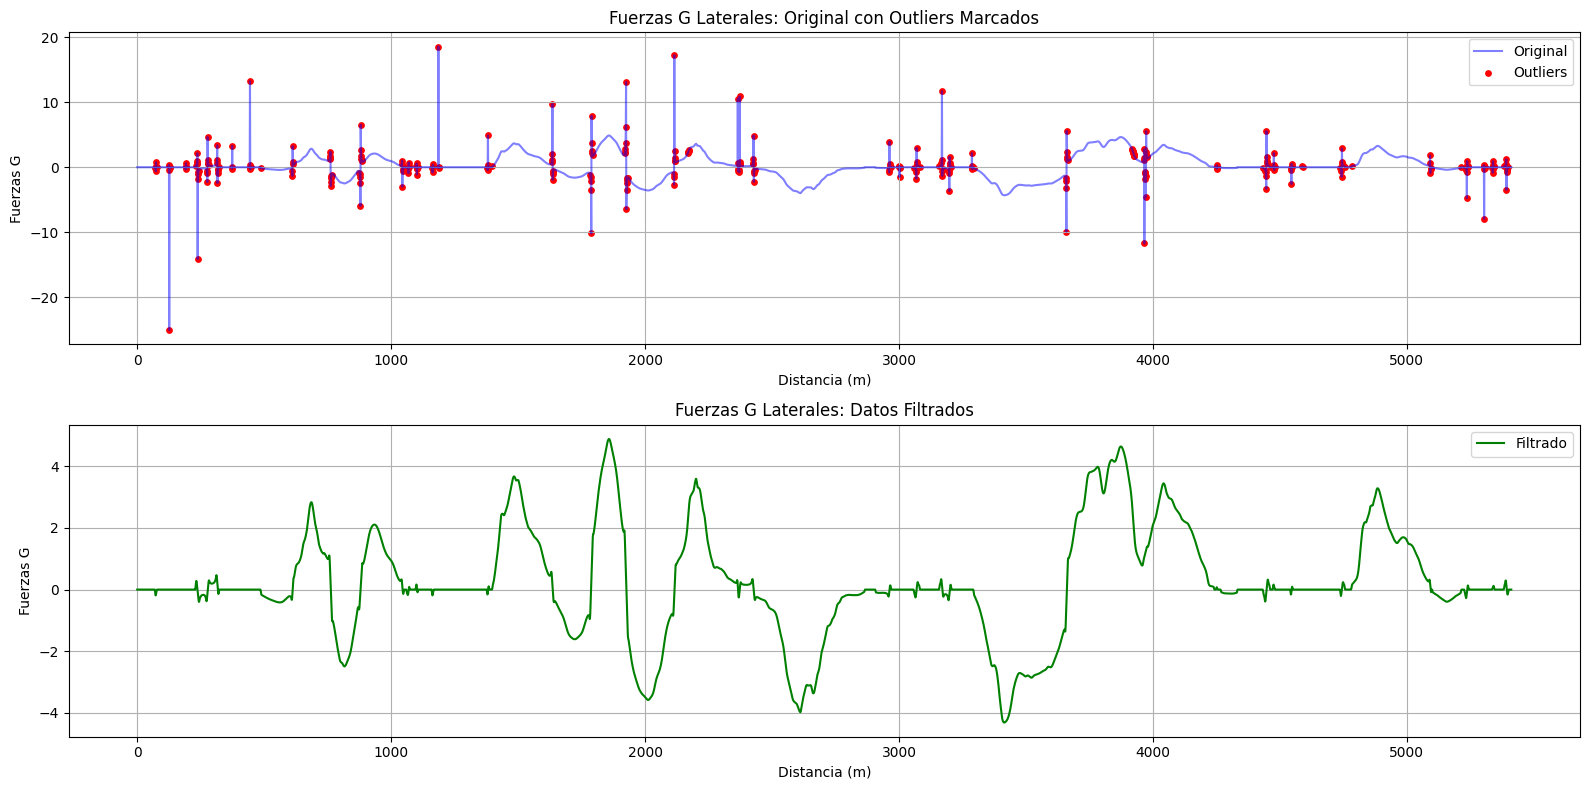

In [7]:
# Aplicar la función a tu DataFrame df_combined
df_cleaned =df_combined_driver1.copy()

plt.figure(figsize=(16, 8))

# Gráfica de fuerzas G originales
plt.subplot(2, 1, 1)
plt.plot(df_cleaned['Distance'], df_cleaned['Lateral_G'], color='blue', alpha=0.5, label='Original')
# Marcar los outliers
plt.scatter(df_cleaned.loc[df_cleaned['lateral_g_outlier'], 'Distance'], 
            df_cleaned.loc[df_cleaned['lateral_g_outlier'], 'Lateral_G'], 
            color='red', s=15, label='Outliers')
plt.title('Fuerzas G Laterales: Original con Outliers Marcados')
plt.xlabel('Distancia (m)')
plt.ylabel('Fuerzas G')
plt.grid(True)
plt.legend()

# Gráfica de fuerzas G filtradas
plt.subplot(2, 1, 2)
plt.plot(df_cleaned['Distance'], df_cleaned['lateral_g_filtered'], color='green', label='Filtrado')
plt.title('Fuerzas G Laterales: Datos Filtrados')
plt.xlabel('Distancia (m)')
plt.ylabel('Fuerzas G')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# Ejemplo de uso:
df_combined_driver1['radio_final'] = df_combined_driver1['Radius']
df_combined_driver1['aceleracion_lateral'] = df_combined_driver1['Lateral_G']
df_combined_driver1['X_scaled'] = df_combined_driver1['X']
df_combined_driver1['Y_scaled'] = df_combined_driver1['Y']
fig_track_speed, fig_track_g = visualize_track_telemetry(df_combined_driver1)

# Mostrar las figuras:
fig_track_speed.show()
fig_track_g.show()

In [21]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Definir las posiciones de los sectores
sector1_end = 1650  # Fin del sector 1 en metros
sector2_end = 3900  # Fin del sector 2 en metros
# El sector 3 termina al final de la vuelta (5451m)


#track_length = 5807  # Longitud total de la pista en metros

# Definir las posiciones de las curvas principales
# Formato: [posición en metros, número de curva]

track_corners = [
    [700, 1],
    [810, 2],
    [920, 3],
    [1500, 4],
    [1710, 5],
    [1850, 6],
    [2000, 7],
    [2230, 8],
    [2580, 9],
    [2700, 10],
    [3500, 11],
    [3785, 12],
    [4090, 13],
    [4900, 14],
    [5000, 15]
]


# Extraer solo las posiciones de las curvas para las grid lines
corner_positions = [corner[0] for corner in track_corners]

# Modificar la estructura de subplots para tener 4 gauge charts en la primera fila
fig = make_subplots(
        rows=4, 
        cols=12,  # Cambiar a 4 columnas para los gauge charts
        row_heights=[.7, 5, 1, 2], 
        shared_xaxes=True,
        specs=[
            # Primera fila: 4 indicadores separados
            [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
            # Segunda fila en adelante: gráficos que abarcan todas las columnas
            [{"colspan": 12}, None, None, None, None, None, None, None, None, None, None, None],     
            [{"colspan": 12}, None, None, None, None, None, None, None, None, None, None, None],     
            [{"colspan": 12}, None, None, None, None, None, None, None, None, None, None, None]     
        ], 
        vertical_spacing=0.05)

fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white'),
    margin=dict(t=200, l=50, r=50, b=50),
    height= 1080,
    width= 1920,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    )
)



# Calcular estadísticas para ambos pilotos
def calculate_stats(telemetry_df,df_combined):
    stats = {}
    # Porcentaje de tiempo con acelerador a fondo (>90%)
    stats['full_throttle_pct'] = (telemetry_df['Throttle'] >= 95).mean() * 100
    stats['top_speed'] = telemetry_df['Speed'].max()
    print(stats['full_throttle_pct'])
    print((telemetry_df['Throttle'] == 100).mean() * 100)
    print((telemetry_df['Throttle'] == 100).mean())
    # Porcentaje de tiempo frenando (>10%)
    stats['braking_pct'] = (telemetry_df['Brake'] > 0).mean() * 100
    #df_combined['lateral_g_filtered'] = df_combined['lateral_g_filtered'].abs()
    stats['lat_g'] = (df_combined['lateral_g_filtered']).abs().mean()
    #stats['lon_g'] = (df_combined['Brake'] > 0).mean() * 100
    # Velocidad media
    stats['avg_speed'] = telemetry_df['Speed'].mean()
    
    # Velocidad máxima
    stats['max_speed'] = telemetry_df['Speed'].max()
    return stats

driver1_stats = calculate_stats(fl1_tel_interpolated,df_combined_driver1)
driver2_stats = calculate_stats(fl2_tel_interpolated,df_combined_driver2)
print(driver1_stats)
print(driver2_stats)

fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['full_throttle_pct'],
        title={"text": "Full Throttle %", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['full_throttle_pct'], "font": {"color": "white", "size": 12}},
        gauge={
            "axis": {
                "range": [0, 100], 
                "tickcolor": "black",
                "tickvals": [0, 20, 40, 60, 80, 100],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "green"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": "%", "font": {"color": "white", "size": 12}}
    ),
    row=1, col=1)

# Hamilton - Acelerador (segunda columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['braking_pct'],
        title={"text": "Braking", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['braking_pct'], "font": {"color": "white", "size": 12},"decreasing": {"color": "green"},"increasing": {"color": "red"},"valueformat": ".1f"},
        gauge={
            "axis": {
                "range": [0, 100], 
                "tickcolor": "black",
                "tickvals": [0, 20, 40, 60, 80, 100],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "red"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": "%", "font": {"color": "white", "size": 12}}
    ),
    row=1, col=2
)
print(driver1_stats['lat_g'])
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['lat_g'],
        title={"text": "G forces", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['lat_g'], "font": {"color": "white", "size": 12}},
        gauge={
            "axis": {
                "range": [0, 5], 
                "tickcolor": "black",
                "tickvals": [0, 1, 2, 3, 4, 5],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "red"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": " G", "font": {"color": "white", "size": 10}}
    ),
    row=1, col=3
)

# Hamilton - Acelerador (segunda columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['top_speed'],
        title={"text": "Max Speed", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['top_speed'], "font": {"color": "white", "size": 12}},
        gauge={
            "axis": {
                "range": [0, 350], 
                "tickcolor": "black",
                "tickvals": [0, 50, 100, 250, 200, 250, 300, 350],
                "ticktext": ["", "","", "", "", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "red"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": " km/h", "font": {"color": "white", "size": 12}}
    ),
    row=1, col=4
)



#--------IMAGENES--------

fig.add_layout_image(
    dict(
        source="Sainz.png",
        xref="paper", yref="paper",
        x=0.1,  # Centrado horizontalmente (0.5 es el centro)
        y=1.2,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=.2,  # Ancho de la imagen
        sizey=.2,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,

        layer="above"  # Rotación de la imagen (en grados)
    )
)
fig.add_layout_image(
    dict(
        source="track_performance_map.png",
        xref="paper", yref="paper",
        x=0.5,  # Centrado horizontalmente (0.5 es el centro)
        y=1.05,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=0.35,  # Ancho de la imagen
        sizey=0.35,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,
        layer="above"
    )
)





# Configurar las líneas de cuadrícula para que estén alineadas con las curvas
fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    
    gridcolor='rgba(128, 128, 128, .2)',
    zeroline=False,
    griddash='dot',
    dtick=None,  # Eliminamos el dtick predeterminado
    tickvals=corner_positions,  # Usar las posiciones de las curvas para las líneas verticales
    ticktext=["" for _ in corner_positions]  # Texto vacío para no mostrar etiquetas numéricas
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128, 128, 128, 0.3)',
    zeroline=False
)



'''# Añadir líneas verticales para los sectores específicamente en la gráfica de speed (row=2, col=1)
fig.add_shape(
    type="line",
    x0=sector1_end, y0=0,
    x1=sector1_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

fig.add_shape(
    type="line",
    x0=sector2_end, y0=0,
    x1=sector2_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

# Añadir etiquetas para los sectores en la parte superior del gráfico
fig.add_annotation(
    x=sector1_end/2, 
    y=.85,
    xref="x", 
    yref="paper",
    text="Sector 1",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector1_end + sector2_end)/2, 
    y=.85,
    xref="x", 
    yref="paper",
    text="Sector 2",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector2_end + track_length)/2, 
    y=.85,
    xref="x", 
    yref="paper",
    text="Sector 3",
    showarrow=False,
    font=dict(color="yellow", size=14),
)


'''
# Reemplaza el código actual de sectores verticales con este nuevo código
# Eliminar primero las líneas verticales y anotaciones de sectores existentes

# Definir colores para cada sector
sector_colors = {
    1: 'red',      # Sector 1: rojo
    2: 'skyblue',     # Sector 2: azul
    3: 'yellow'    # Sector 3: amarillo
}

# Añadir barras horizontales para cada sector en la parte superior de la gráfica
# Sector 1
fig.add_shape(
    type="rect",
    x0=0, 
    x1=sector1_end,
    y0=0.9, 
    y1=.895,
    line=dict(width=0),
    fillcolor=sector_colors[1],
    opacity=1,
    xref="x", 
    yref="paper",
    layer="above"
)

# Sector 2
fig.add_shape(
    type="rect",
    x0=sector1_end, 
    x1=sector2_end,
    y0=0.9, 
    y1=0.895,
    line=dict(width=0),
    fillcolor=sector_colors[2],
    opacity=1,
    xref="x", 
    yref="paper",
    layer="above"
)

# Sector 3
fig.add_shape(
    type="rect",
    x0=sector2_end, 
    x1=track_length,
    y0=0.9, 
    y1=.895,
    line=dict(width=0),
    fillcolor=sector_colors[3],
    opacity=1,
    xref="x", 
    yref="paper",
    layer="above"
)

# Añadir etiquetas de sector encima de las barras de colores
fig.add_annotation(
    x=sector1_end/2, 
    y=0.896,
    xref="x", 
    yref="paper",
    text="S1",
    showarrow=False,
    font=dict(color="white", size=10, family="Arial Black"),
    bgcolor="rgba(0,0,0,0)"
)

fig.add_annotation(
    x=(sector1_end + sector2_end)/2, 
    y=0.896,
    xref="x", 
    yref="paper",
    text="S2",
    showarrow=False,
    font=dict(color="white", size=10, family="Arial Black"),
    bgcolor="rgba(0,0,0,0)"
)

fig.add_annotation(
    x=(sector2_end + track_length)/2, 
    y=0.896,
    xref="x", 
    yref="paper",
    text="S3",
    showarrow=False,
    font=dict(color="white", size=10, family="Arial Black"),
    bgcolor="rgba(0,0,0,0)"
)





# Obtener el rango de velocidades para posicionar las etiquetas
try:
    speed_min = min(fl1_tel['Speed'].min(), fl2_tel['Speed'].min())
    speed_max = max(fl1_tel['Speed'].max(), fl2_tel['Speed'].max())
    # Posicionar las etiquetas en la parte inferior del gráfico de velocidad
    label_y_pos = speed_min - (speed_max - speed_min) * 0.08  # Reducido el espacio para etiquetas horizontales
except:
    # En caso de error, usar un valor predeterminado
    label_y_pos = 0







# Añadir etiquetas horizontales para cada curva en la sección de velocidad
for corner in track_corners:
    position, number = corner
    
    # Añadir etiqueta para el número de curva (ahora horizontal)
    fig.add_annotation(
        x=position,
        y=-20,  # Ajustado para texto horizontal
        text=f"T{number}",  # "T" de "Turn"
        showarrow=False,
        font=dict(color="cyan", size=10),
        xref="x", 
        yref="y1",
        bgcolor="rgba(0,0,0,1)",
        yshift=0,  # Ajustado para texto horizontal
        xshift=0,
        textangle=0,  # Texto horizontal
        row=2, col=1
    )







# Speed plot
'''fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)'''
fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,  # Asegúrate que este valor es correcto
    col=1
)
fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['Speed'],
    x=fl2_tel_interpolated['Distance'],
    mode='lines',
    name='Hamilton',
    line=dict(color='white', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)
# Throttle plot
fig.add_trace(go.Scatter(
    y=fl1_tel['Throttle'], 
    x=fl1_tel['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=2, 
    col=1
)

fig.add_trace(go.Scatter(
    y=fl2_tel['Throttle'], 
    x=fl2_tel['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='white', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=2, 
    col=1
)




#DELTA TIME PLOT--------------------

# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=1, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y2"
)
# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=.3, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y3"
)

'''# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=1, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y4"
)'''

# Añadir anotaciones explicativas para el delta de tiempo
delta_max = delta_df_interpolated['DeltaTime'].max()
delta_min = delta_df_interpolated['DeltaTime'].min()
y_pos_top = delta_max + (delta_max - delta_min) * 0.1
y_pos_bottom = delta_min - (delta_max - delta_min) * 0.1

# Versión más eficiente para el gráfico de delta con colores
# Preparar los datos para segmentos
segments = []
current_segment = {'x': [], 'y': [], 'color': None}

# Definir color inicial
last_color = 'white' if delta_df_interpolated['DeltaTime'].iloc[0] > 0 else 'red'
current_segment['color'] = last_color
current_segment['x'].append(delta_df_interpolated['Distance'].iloc[0])
current_segment['y'].append(delta_df_interpolated['DeltaTime'].iloc[0])

# Agrupar puntos consecutivos del mismo color
for i in range(1, len(delta_df_interpolated)):
    current_delta = delta_df_interpolated['DeltaTime'].iloc[i]
    current_dist = delta_df_interpolated['Distance'].iloc[i]
    
    # Determinar el color actual
    current_color = 'white' if current_delta > 0 else 'red'
    
    # Si cambia el color, terminar el segmento actual y comenzar uno nuevo
    if current_color != last_color:
        # Añadir el punto actual al segmento anterior para evitar gaps
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)
        
        # Guardar el segmento completo
        segments.append(current_segment)
        
        # Iniciar nuevo segmento con el punto actual
        current_segment = {'x': [current_dist], 'y': [current_delta], 'color': current_color}
        last_color = current_color
    else:
        # Añadir el punto al segmento actual
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)

# Añadir el último segmento
if current_segment['x']:
    segments.append(current_segment)

# Añadir cada segmento como un trazo separado
for i, segment in enumerate(segments):
    fig.add_trace(go.Scatter(
        y=segment['y'], 
        x=segment['x'],
        mode='lines',
        line=dict(color=segment['color'], width=1),
        hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Delta:</b> %{y:.3f}s<extra></extra>',
        showlegend=False),
        row=3, 
        col=1
    )

# Añadir entradas para la leyenda
fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='white', width=2),
    name='Hamilton más rápido'),
    row=2, 
    col=1
)

fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='red', width=2),
    name='Sainz más rápido'),
    row=2, 
    col=1
)





# Brake plot
fig.add_trace(go.Scatter(
    y=df_combined_driver1['longitudinal_aceleration'], 
    x=df_combined_driver1['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=1,dash='dot'),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)

fig.add_trace(go.Scatter(
    y=df_combined_driver2['longitudinal_aceleration'], 
    x=df_combined_driver2['Distance'], 
    mode='lines',
    showlegend=True,
    line=dict(color='white', width=1,dash='dot'),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)


fig.add_trace(go.Scatter(
    y=df_combined_driver1['lateral_g_filtered'], 
    x=df_combined_driver1['Distance'], 
    mode='lines',

    showlegend=False,
    line=dict(color='red', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)
# Throttle plot
fig.add_trace(go.Scatter(
    y=df_combined_driver2['lateral_g_filtered'], 
    x=df_combined_driver2['Distance'], 
    mode='lines',
    
    showlegend=False,
    line=dict(color='white', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)










# Ajustar el rango de visualización del gráfico de velocidad para dejar espacio para las etiquetas horizontales
fig.update_yaxes(range=[label_y_pos - 10, speed_max * 1.05], row=1, col=1)
# Añadir título principal
fig.add_annotation(
    xref='paper',
    yref='paper',
    x=0.5,
    y=1.35,
    text="Titulo ejemplo",
    showarrow=False,
    font=dict(color="white", size=24, family="Arial Black"),
    align="center"
)




add_speed_annotations(
    fig, 
    fl1_tel_interpolated['Distance'].values,  # x1 (Sainz)
    fl1_tel_interpolated['Speed'].values,     # y1 (Sainz)
    fl2_tel_interpolated['Distance'].values,  # x2 (Hamilton)
    fl2_tel_interpolated['Speed'].values,     # y2 (Hamilton)
    'Sainz',                                 # name1
    'Hamilton',                              # name2
    'red',                                   # color1 
    'white',                                 # color2
    offset=20,                               # desplazamiento vertical
    min_peak_speed=250,                      # velocidad mínima para mostrar picos
    row=1                                    # Asegúrate que este valor es correcto
)






# Apply to all subplot rows
# Añadir títulos a los ejes y para cada subplot
fig.update_yaxes(title_text="Speed (km/h)",title_font_size=10, color='white', row=2, col=1)
fig.update_yaxes(title_text="Delta Time (s)",title_font_size=10, color='white', row=3, col=1)
fig.update_yaxes(title_text="Throttle (%)",title_font_size=10, color='white', row=4, col=1)
fig.update_yaxes(title_text="Brake (On/Off)",title_font_size=10, color='white', row=5, col=1)
fig.update_yaxes(title_text="Gear",title_font_size=10, color='white', row=6, col=1)
fig.update_xaxes(title_text="Distance (m)", color='white', row=6, col=1)

# Añadir títulos a los ejes y para cada subplot con alineación consistente
fig.update_yaxes(
    title=dict(
        text="Speed (km/h)",
        font=dict(size=10, color='white'),
        standoff=0   # Distancia entre el título y el eje
    ),
    title_standoff=25,   # Distancia consistente para todos los títulos
    row=2, col=1
)

fig.update_yaxes(
    title=dict(
        text="Delta Time (s)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=3, col=1
)

fig.update_yaxes(
    title=dict(
        text="Throttle (%)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=4, col=1
)

fig.update_yaxes(
    title=dict(
        text="Brake (On/Off)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=5, col=1
)

fig.update_yaxes(
    title=dict(
        text="Gear",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=6, col=1
)

fig.update_xaxes(
    title=dict(
        text="Distance (m)",
        font=dict(size=10, color='white')
    ),
    row=6, col=1
)

# Mostrar la gráfica
fig.show()

70.91648189209164
27.4759793052476
0.274759793052476
68.53288987435329
1.0901699926090171
0.01090169992609017
{'full_throttle_pct': 70.91648189209164, 'top_speed': 318.9927187005275, 'braking_pct': 17.53510716925351, 'lat_g': 1.142120498737723, 'avg_speed': 236.9124767983209, 'max_speed': 318.9927187005275}
{'full_throttle_pct': 68.53288987435329, 'top_speed': 315.0, 'braking_pct': 15.188470066518848, 'lat_g': 1.1309656793321843, 'avg_speed': 237.53026963015725, 'max_speed': 315.0}
1.142120498737723


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Definir las posiciones de los sectores
sector1_end = 1650  # Fin del sector 1 en metros
sector2_end = 3900  # Fin del sector 2 en metros
# El sector 3 termina al final de la vuelta (5451m)


#track_length = 5807  # Longitud total de la pista en metros

# Definir las posiciones de las curvas principales
# Formato: [posición en metros, número de curva]

track_corners = [
    [700, 1],
    [810, 2],
    [920, 3],
    [1500, 4],
    [1710, 5],
    [1850, 6],
    [2000, 7],
    [2230, 8],
    [2580, 9],
    [2700, 10],
    [3500, 11],
    [3785, 12],
    [4090, 13],
    [4900, 14],
    [5000, 15]
]


# Extraer solo las posiciones de las curvas para las grid lines
corner_positions = [corner[0] for corner in track_corners]

# Modificar la estructura de subplots para tener 4 gauge charts en la primera fila
fig = make_subplots(
        rows=4, 
        cols=12,  # Cambiar a 4 columnas para los gauge charts
        row_heights=[.7, 5, 1, 2], 
        shared_xaxes=True,
        specs=[
            # Primera fila: 4 indicadores separados
            [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
            # Segunda fila en adelante: gráficos que abarcan todas las columnas
            [{"colspan": 12}, None, None, None, None, None, None, None, None, None, None, None],     
            [{"colspan": 12}, None, None, None, None, None, None, None, None, None, None, None],     
            [{"colspan": 12}, None, None, None, None, None, None, None, None, None, None, None]     
        ], 
        vertical_spacing=0.05)

fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white'),
    margin=dict(t=200, l=50, r=50, b=50),
    height= 1080,
    width= 1920,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    )
)



# Calcular estadísticas para ambos pilotos
def calculate_stats(telemetry_df,df_combined):
    stats = {}
    # Porcentaje de tiempo con acelerador a fondo (>90%)
    stats['full_throttle_pct'] = (telemetry_df['Throttle'] >= 95).mean() * 100
    stats['top_speed'] = telemetry_df['Speed'].max()
    print(stats['full_throttle_pct'])
    print((telemetry_df['Throttle'] == 100).mean() * 100)
    print((telemetry_df['Throttle'] == 100).mean())
    # Porcentaje de tiempo frenando (>10%)
    stats['braking_pct'] = (telemetry_df['Brake'] > 0).mean() * 100
    #df_combined['lateral_g_filtered'] = df_combined['lateral_g_filtered'].abs()
    stats['lat_g'] = (df_combined['lateral_g_filtered']).abs().mean()
    #stats['lon_g'] = (df_combined['Brake'] > 0).mean() * 100
    # Velocidad media
    stats['avg_speed'] = telemetry_df['Speed'].mean()
    
    # Velocidad máxima
    stats['max_speed'] = telemetry_df['Speed'].max()
    return stats

driver1_stats = calculate_stats(fl1_tel_interpolated,df_combined_driver1)
driver2_stats = calculate_stats(fl2_tel_interpolated,df_combined_driver2)
print(driver1_stats)
print(driver2_stats)

fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['full_throttle_pct'],
        title={"text": "Full Throttle %", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['full_throttle_pct'], "font": {"color": "white", "size": 12}},
        gauge={
            "axis": {
                "range": [0, 100], 
                "tickcolor": "black",
                "tickvals": [0, 20, 40, 60, 80, 100],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "green"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": "%", "font": {"color": "white", "size": 12}}
    ),
    row=1, col=1)

# Hamilton - Acelerador (segunda columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['braking_pct'],
        title={"text": "Braking", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['braking_pct'], "font": {"color": "white", "size": 12},"decreasing": {"color": "green"},"increasing": {"color": "red"},"valueformat": ".1f"},
        gauge={
            "axis": {
                "range": [0, 100], 
                "tickcolor": "black",
                "tickvals": [0, 20, 40, 60, 80, 100],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "red"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": "%", "font": {"color": "white", "size": 12}}
    ),
    row=1, col=2
)
print(driver1_stats['lat_g'])
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['lat_g'],
        title={"text": "G forces", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['lat_g'], "font": {"color": "white", "size": 12}},
        gauge={
            "axis": {
                "range": [0, 5], 
                "tickcolor": "black",
                "tickvals": [0, 1, 2, 3, 4, 5],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "red"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": " G", "font": {"color": "white", "size": 10}}
    ),
    row=1, col=3
)

# Hamilton - Acelerador (segunda columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['top_speed'],
        title={"text": "Max Speed", "font": {"color": "white", "size": 12}},
        delta = {'reference': driver2_stats['top_speed'], "font": {"color": "white", "size": 12}},
        gauge={
            "axis": {
                "range": [0, 350], 
                "tickcolor": "black",
                "tickvals": [0, 50, 100, 250, 200, 250, 300, 350],
                "ticktext": ["", "","", "", "", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "red"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": " km/h", "font": {"color": "white", "size": 12}}
    ),
    row=1, col=4
)



#--------IMAGENES--------

fig.add_layout_image(
    dict(
        source="Sainz.png",
        xref="paper", yref="paper",
        x=0.1,  # Centrado horizontalmente (0.5 es el centro)
        y=1.2,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=.2,  # Ancho de la imagen
        sizey=.2,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,

        layer="above"  # Rotación de la imagen (en grados)
    )
)
fig.add_layout_image(
    dict(
        source="track_performance_map.png",
        xref="paper", yref="paper",
        x=0.5,  # Centrado horizontalmente (0.5 es el centro)
        y=1.05,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=0.35,  # Ancho de la imagen
        sizey=0.35,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,
        layer="above"
    )
)





# Configurar las líneas de cuadrícula para que estén alineadas con las curvas
fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    
    gridcolor='rgba(128, 128, 128, .2)',
    zeroline=False,
    griddash='dot',
    dtick=None,  # Eliminamos el dtick predeterminado
    tickvals=corner_positions,  # Usar las posiciones de las curvas para las líneas verticales
    ticktext=["" for _ in corner_positions]  # Texto vacío para no mostrar etiquetas numéricas
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128, 128, 128, 0.3)',
    zeroline=False
)



'''# Añadir líneas verticales para los sectores específicamente en la gráfica de speed (row=2, col=1)
fig.add_shape(
    type="line",
    x0=sector1_end, y0=0,
    x1=sector1_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

fig.add_shape(
    type="line",
    x0=sector2_end, y0=0,
    x1=sector2_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

# Añadir etiquetas para los sectores en la parte superior del gráfico
fig.add_annotation(
    x=sector1_end/2, 
    y=.85,
    xref="x", 
    yref="paper",
    text="Sector 1",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector1_end + sector2_end)/2, 
    y=.85,
    xref="x", 
    yref="paper",
    text="Sector 2",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector2_end + track_length)/2, 
    y=.85,
    xref="x", 
    yref="paper",
    text="Sector 3",
    showarrow=False,
    font=dict(color="yellow", size=14),
)


'''
# Reemplaza el código actual de sectores verticales con este nuevo código
# Eliminar primero las líneas verticales y anotaciones de sectores existentes

# Definir colores para cada sector
sector_colors = {
    1: 'red',      # Sector 1: rojo
    2: 'skyblue',     # Sector 2: azul
    3: 'yellow'    # Sector 3: amarillo
}

# Añadir barras horizontales para cada sector en la parte superior de la gráfica
# Sector 1
fig.add_shape(
    type="rect",
    x0=0, 
    x1=sector1_end,
    y0=0.9, 
    y1=.895,
    line=dict(width=0),
    fillcolor=sector_colors[1],
    opacity=1,
    xref="x", 
    yref="paper",
    layer="above"
)

# Sector 2
fig.add_shape(
    type="rect",
    x0=sector1_end, 
    x1=sector2_end,
    y0=0.9, 
    y1=0.895,
    line=dict(width=0),
    fillcolor=sector_colors[2],
    opacity=1,
    xref="x", 
    yref="paper",
    layer="above"
)

# Sector 3
fig.add_shape(
    type="rect",
    x0=sector2_end, 
    x1=track_length,
    y0=0.9, 
    y1=.895,
    line=dict(width=0),
    fillcolor=sector_colors[3],
    opacity=1,
    xref="x", 
    yref="paper",
    layer="above"
)

# Añadir etiquetas de sector encima de las barras de colores
fig.add_annotation(
    x=sector1_end/2, 
    y=0.896,
    xref="x", 
    yref="paper",
    text="S1",
    showarrow=False,
    font=dict(color="white", size=10, family="Arial Black"),
    bgcolor="rgba(0,0,0,0)"
)

fig.add_annotation(
    x=(sector1_end + sector2_end)/2, 
    y=0.896,
    xref="x", 
    yref="paper",
    text="S2",
    showarrow=False,
    font=dict(color="white", size=10, family="Arial Black"),
    bgcolor="rgba(0,0,0,0)"
)

fig.add_annotation(
    x=(sector2_end + track_length)/2, 
    y=0.896,
    xref="x", 
    yref="paper",
    text="S3",
    showarrow=False,
    font=dict(color="white", size=10, family="Arial Black"),
    bgcolor="rgba(0,0,0,0)"
)





# Obtener el rango de velocidades para posicionar las etiquetas
try:
    speed_min = min(fl1_tel['Speed'].min(), fl2_tel['Speed'].min())
    speed_max = max(fl1_tel['Speed'].max(), fl2_tel['Speed'].max())
    # Posicionar las etiquetas en la parte inferior del gráfico de velocidad
    label_y_pos = speed_min - (speed_max - speed_min) * 0.08  # Reducido el espacio para etiquetas horizontales
except:
    # En caso de error, usar un valor predeterminado
    label_y_pos = 0







# Añadir etiquetas horizontales para cada curva en la sección de velocidad
for corner in track_corners:
    position, number = corner
    
    # Añadir etiqueta para el número de curva (ahora horizontal)
    fig.add_annotation(
        x=position,
        y=-20,  # Ajustado para texto horizontal
        text=f"T{number}",  # "T" de "Turn"
        showarrow=False,
        font=dict(color="cyan", size=10),
        xref="x", 
        yref="y1",
        bgcolor="rgba(0,0,0,1)",
        yshift=0,  # Ajustado para texto horizontal
        xshift=0,
        textangle=0,  # Texto horizontal
        row=2, col=1
    )







# Speed plot
'''fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)'''
fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,  # Asegúrate que este valor es correcto
    col=1
)
fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['Speed'],
    x=fl2_tel_interpolated['Distance'],
    mode='lines',
    name='Hamilton',
    line=dict(color='white', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)
# Throttle plot
fig.add_trace(go.Scatter(
    y=fl1_tel['Throttle'], 
    x=fl1_tel['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=2, 
    col=1
)

fig.add_trace(go.Scatter(
    y=fl2_tel['Throttle'], 
    x=fl2_tel['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='white', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=2, 
    col=1
)




#DELTA TIME PLOT--------------------

# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=1, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y2"
)
# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=.3, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y3"
)

'''# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=1, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y4"
)'''

# Añadir anotaciones explicativas para el delta de tiempo
delta_max = delta_df_interpolated['DeltaTime'].max()
delta_min = delta_df_interpolated['DeltaTime'].min()
y_pos_top = delta_max + (delta_max - delta_min) * 0.1
y_pos_bottom = delta_min - (delta_max - delta_min) * 0.1

# Versión más eficiente para el gráfico de delta con colores
# Preparar los datos para segmentos
segments = []
current_segment = {'x': [], 'y': [], 'color': None}

# Definir color inicial
last_color = 'white' if delta_df_interpolated['DeltaTime'].iloc[0] > 0 else 'red'
current_segment['color'] = last_color
current_segment['x'].append(delta_df_interpolated['Distance'].iloc[0])
current_segment['y'].append(delta_df_interpolated['DeltaTime'].iloc[0])

# Agrupar puntos consecutivos del mismo color
for i in range(1, len(delta_df_interpolated)):
    current_delta = delta_df_interpolated['DeltaTime'].iloc[i]
    current_dist = delta_df_interpolated['Distance'].iloc[i]
    
    # Determinar el color actual
    current_color = 'white' if current_delta > 0 else 'red'
    
    # Si cambia el color, terminar el segmento actual y comenzar uno nuevo
    if current_color != last_color:
        # Añadir el punto actual al segmento anterior para evitar gaps
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)
        
        # Guardar el segmento completo
        segments.append(current_segment)
        
        # Iniciar nuevo segmento con el punto actual
        current_segment = {'x': [current_dist], 'y': [current_delta], 'color': current_color}
        last_color = current_color
    else:
        # Añadir el punto al segmento actual
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)

# Añadir el último segmento
if current_segment['x']:
    segments.append(current_segment)

# Añadir cada segmento como un trazo separado
for i, segment in enumerate(segments):
    fig.add_trace(go.Scatter(
        y=segment['y'], 
        x=segment['x'],
        mode='lines',
        line=dict(color=segment['color'], width=1),
        hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Delta:</b> %{y:.3f}s<extra></extra>',
        showlegend=False),
        row=3, 
        col=1
    )

# Añadir entradas para la leyenda
fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='white', width=2),
    name='Hamilton más rápido'),
    row=2, 
    col=1
)

fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='red', width=2),
    name='Sainz más rápido'),
    row=2, 
    col=1
)





# Brake plot
fig.add_trace(go.Scatter(
    y=df_combined_driver1['longitudinal_aceleration'], 
    x=df_combined_driver1['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=1,dash='dot'),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)

fig.add_trace(go.Scatter(
    y=df_combined_driver2['longitudinal_aceleration'], 
    x=df_combined_driver2['Distance'], 
    mode='lines',
    showlegend=True,
    line=dict(color='white', width=1,dash='dot'),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)


fig.add_trace(go.Scatter(
    y=df_combined_driver1['lateral_g_filtered'], 
    x=df_combined_driver1['Distance'], 
    mode='lines',

    showlegend=False,
    line=dict(color='red', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)
# Throttle plot
fig.add_trace(go.Scatter(
    y=df_combined_driver2['lateral_g_filtered'], 
    x=df_combined_driver2['Distance'], 
    mode='lines',
    
    showlegend=False,
    line=dict(color='white', width=.5),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)










# Ajustar el rango de visualización del gráfico de velocidad para dejar espacio para las etiquetas horizontales
fig.update_yaxes(range=[label_y_pos - 10, speed_max * 1.05], row=1, col=1)
# Añadir título principal
fig.add_annotation(
    xref='paper',
    yref='paper',
    x=0.5,
    y=1.35,
    text="Titulo ejemplo",
    showarrow=False,
    font=dict(color="white", size=24, family="Arial Black"),
    align="center"
)




add_speed_annotations(
    fig, 
    fl1_tel_interpolated['Distance'].values,  # x1 (Sainz)
    fl1_tel_interpolated['Speed'].values,     # y1 (Sainz)
    fl2_tel_interpolated['Distance'].values,  # x2 (Hamilton)
    fl2_tel_interpolated['Speed'].values,     # y2 (Hamilton)
    'Sainz',                                 # name1
    'Hamilton',                              # name2
    'red',                                   # color1 
    'white',                                 # color2
    offset=20,                               # desplazamiento vertical
    min_peak_speed=250,                      # velocidad mínima para mostrar picos
    row=1                                    # Asegúrate que este valor es correcto
)






# Apply to all subplot rows
# Añadir títulos a los ejes y para cada subplot
fig.update_yaxes(title_text="Speed (km/h)",title_font_size=10, color='white', row=2, col=1)
fig.update_yaxes(title_text="Delta Time (s)",title_font_size=10, color='white', row=3, col=1)
fig.update_yaxes(title_text="Throttle (%)",title_font_size=10, color='white', row=4, col=1)
fig.update_yaxes(title_text="Brake (On/Off)",title_font_size=10, color='white', row=5, col=1)
fig.update_yaxes(title_text="Gear",title_font_size=10, color='white', row=6, col=1)
fig.update_xaxes(title_text="Distance (m)", color='white', row=6, col=1)

# Añadir títulos a los ejes y para cada subplot con alineación consistente
fig.update_yaxes(
    title=dict(
        text="Speed (km/h)",
        font=dict(size=10, color='white'),
        standoff=0   # Distancia entre el título y el eje
    ),
    title_standoff=25,   # Distancia consistente para todos los títulos
    row=2, col=1
)

fig.update_yaxes(
    title=dict(
        text="Delta Time (s)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=3, col=1
)

fig.update_yaxes(
    title=dict(
        text="Throttle (%)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=4, col=1
)

fig.update_yaxes(
    title=dict(
        text="Brake (On/Off)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=5, col=1
)

fig.update_yaxes(
    title=dict(
        text="Gear",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=6, col=1
)

fig.update_xaxes(
    title=dict(
        text="Distance (m)",
        font=dict(size=10, color='white')
    ),
    row=6, col=1
)

# Mostrar la gráfica
fig.show()

In [10]:
df_combined_driver1[df_combined_driver1['lateral_g_filtered']<0]

,Distance,Speed,Time,nGear,RPM,Throttle,Brake,Date,Status,X,...,acceleration_ms2,longitudinal_aceleration,Radius,TurnDirection,Lateral_G,lateral_g_outlier,outlier_reason,lateral_g_filtered,radio_final,aceleracion_lateral
70,70.0,305.293849,0.825524,8,10763.104735,99.706151,0.0,NaT,None,-355.770020,...,1.157407,0.117982,6435.364624,0,-0.000000,False,,-0.039173,6435.364624,-0.000000
71,71.0,305.342506,0.837202,8,10765.440302,99.657494,0.0,NaT,None,-355.728072,...,1.157407,0.117982,4880.910272,-1,-0.150245,True,Cambio brusco improbable;,-0.117518,4880.910272,-0.150245
72,72.0,305.391164,0.848879,8,10767.775869,99.608836,0.0,NaT,None,-355.686125,...,1.157407,0.117982,3121.068420,-1,-0.235037,False,,-0.180195,3121.068420,-0.235037
73,73.0,305.439822,0.860557,8,10770.111436,99.560178,0.0,NaT,None,-355.644177,...,1.157407,0.117982,1164.726281,-1,-0.630019,True,Cambio brusco improbable;,-0.188029,1164.726281,-0.630019
74,74.0,305.488479,0.872235,8,10772.447004,99.511521,0.0,NaT,None,-355.602229,...,1.157407,0.117982,968.367116,1,0.758011,True,Desviación estadística significativa;Cambio br...,-0.141022,968.367116,0.758011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396,5396.0,288.270135,90.068477,7,NaN,99.000000,0.0,NaT,None,-359.490789,...,1.021242,0.104102,3370.628889,-1,-0.193916,False,,-0.155321,3370.628889,-0.193916
5397,5397.0,288.315752,90.080884,7,NaN,99.000000,0.0,NaT,None,-359.446744,...,1.021242,0.104102,4192.761493,-1,-0.155942,False,,-0.160282,4192.761493,-0.155942
5398,5398.0,288.361368,90.093292,7,NaN,99.000000,0.0,2025-04-12 17:10:12.632,OnTrack,-359.402699,...,1.021242,0.104102,4993.079333,-1,-0.130988,False,,-0.117475,4993.079333,-0.130988
5399,5399.0,288.406985,90.105700,7,NaN,99.000000,0.0,NaT,None,-359.358654,...,1.021242,0.104102,5758.151039,0,-0.000000,True,Cambio brusco improbable;,-0.065494,5758.151039,-0.000000


In [11]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

def create_track_performance_map(filled_delta_df, fast_df, slow_df, track_name="Track", csv_path="coords.csv", min_segments=3, total_track_length=5451):
    """
    Crea un mapa del circuito que muestra qué piloto es más rápido en cada sección,
    asegurando que no haya huecos en la visualización, incluyendo el segmento entre el final y el inicio.
    
    Args:
        filled_delta_df: DataFrame con la columna 'Fastest'
        fast_df: DataFrame del piloto más rápido
        slow_df: DataFrame del piloto más lento
        track_name: Nombre del circuito
        csv_path: Ruta al archivo CSV con las coordenadas
        min_segments: Número mínimo de segmentos consecutivos para cambiar el color
        total_track_length: Longitud total del circuito en metros (default: 5451m)
    """
    # [Código existente para cargar coordenadas y normalizar]
    # Cargar coordenadas desde el archivo CSV
    track_coords = pd.read_csv(csv_path)
    
    # Extraer coordenadas x, y
    x_coords = track_coords['x'].values
    y_coords = track_coords['y'].values
    
    # Calcular mínimos y máximos
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    # Normalizar coordenadas a un rango [0,1] para x e y
    x_norm = [(x - x_min)/(x_max - x_min) for x in x_coords]
    y_norm = [(y - y_min)/(y_max - y_min) for y in y_coords]
    
    # Cerrar el circuito: añadir el primer punto al final si no está cerrado
    if (x_norm[0] != x_norm[-1]) or (y_norm[0] != y_norm[-1]):
        x_norm.append(x_norm[0])
        y_norm.append(y_norm[0])
        x_coords = np.append(x_coords, x_coords[0])
        y_coords = np.append(y_coords, y_coords[0])
    
    # Calcular la longitud del circuito en segmentos
    track_segments = len(x_norm) - 1
    
    # [Resto del código para calcular distancias]
    # Calcular las distancias acumuladas a lo largo del circuito
    segment_lengths = []
    total_length = 0
    
    for i in range(track_segments):
        # Calcular la distancia euclidiana entre puntos consecutivos
        dx = x_coords[i+1] - x_coords[i]
        dy = y_coords[i+1] - y_coords[i]
        segment_length = np.sqrt(dx**2 + dy**2)
        segment_lengths.append(segment_length)
        total_length += segment_length
    
    # Normalizar las longitudes de segmentos para que la suma sea total_track_length
    scale_factor = total_track_length / total_length
    segment_lengths = [length * scale_factor for length in segment_lengths]
    
    # Calcular las distancias acumuladas en metros
    cumulative_distances = [0]
    for length in segment_lengths:
        cumulative_distances.append(cumulative_distances[-1] + length)

    
    # Aseguramos que los datos están ordenados por distancia
    filled_delta_df = filled_delta_df.sort_values('Distance').reset_index(drop=True)
    fast_df = fast_df.sort_values('Distance').reset_index(drop=True)
    slow_df = slow_df.sort_values('Distance').reset_index(drop=True)

    
    
    # Identificar si fast_df es Hamilton o Sainz
    # Asumimos que si el delta final es positivo, entonces Hamilton es fast_df
    hamilton_is_fast = True if 'DeltaTime' in filled_delta_df.columns and filled_delta_df['DeltaTime'].iloc[-1] > 0 else False
    
    # [Código para determinar quién es más rápido en cada segmento]
    # Para cada segmento del circuito, determinar quién es más rápido
    segment_fastest = []
    segment_hamilton_speed = []
    segment_sainz_speed = []
    
    for i in range(track_segments):
        # Obtener el rango de distancia para este segmento
        start_dist = cumulative_distances[i]
        end_dist = cumulative_distances[i+1]
        mid_dist = (start_dist + end_dist) / 2
        
        # Manejar el caso especial del último segmento que conecta con el inicio
        if i == track_segments - 1 and start_dist > filled_delta_df['Distance'].max():
            # Para el segmento que cierra el circuito, usar el primer y último punto de datos
            fast_start_idx = fast_df['Distance'].idxmin()
            fast_end_idx = fast_df['Distance'].idxmax()
            slow_start_idx = slow_df['Distance'].idxmin()
            slow_end_idx = slow_df['Distance'].idxmax()
            
            # Calcular velocidades promedio para este segmento
            fast_speed = (fast_df.loc[fast_start_idx, 'Speed'] + fast_df.loc[fast_end_idx, 'Speed']) / 2
            slow_speed = (slow_df.loc[slow_start_idx, 'Speed'] + slow_df.loc[slow_end_idx, 'Speed']) / 2
        else:
            # Encontrar los puntos de telemetría más cercanos a esta distancia
            fast_idx = (fast_df['Distance'] - mid_dist).abs().idxmin()
            slow_idx = (slow_df['Distance'] - mid_dist).abs().idxmin()
            
            # Obtener las velocidades
            fast_speed = fast_df.loc[fast_idx, 'Speed']
            slow_speed = slow_df.loc[slow_idx, 'Speed']
        
        # Asignar velocidades a Hamilton y Sainz según quién es más rápido
        if hamilton_is_fast:
            hamilton_speed = fast_speed
            sainz_speed = slow_speed
        else:
            hamilton_speed = slow_speed
            sainz_speed = fast_speed
        
        # Determinar quién es más rápido basado en la velocidad
        speed_based_fastest = -1 if hamilton_speed > sainz_speed else 1
        
        segment_fastest.append(speed_based_fastest)
        segment_hamilton_speed.append(hamilton_speed)
        segment_sainz_speed.append(sainz_speed)
    
    # [Resto del código para crear y filtrar el DataFrame de segmentos]
    # Crear DataFrame para los segmentos
    segment_df = pd.DataFrame({
        'StartDist': cumulative_distances[:-1],
        'EndDist': cumulative_distances[1:],
        'MidDist': [(cumulative_distances[i] + cumulative_distances[i+1])/2 for i in range(track_segments)],
        'Fastest': segment_fastest,
        'HamiltonSpeed': segment_hamilton_speed,
        'SainzSpeed': segment_sainz_speed
    })
    
    # Aplicar el filtro de segmentos mínimos
    segment_df['FilteredFastest'] = segment_df['Fastest'].copy()
    
    # Inicializar con el valor del primer segmento
    current_color = segment_df.loc[0, 'Fastest']
    consecutive_count = 1
    
    # Recorrer todos los segmentos y aplicar la regla de min_segments
    for i in range(1, len(segment_df)):
        if segment_df.loc[i, 'Fastest'] == current_color:
            # Continúa la tendencia actual
            consecutive_count += 1
        else:
            # Potencial cambio de tendencia
            if consecutive_count >= min_segments:
                # La tendencia anterior era lo suficientemente larga, comienza una nueva
                current_color = segment_df.loc[i, 'Fastest']
                consecutive_count = 1
            else:
                # La tendencia anterior no era lo suficientemente larga, mantén el color anterior
                segment_df.loc[i, 'FilteredFastest'] = current_color
                consecutive_count = 1
    
    # Segundo pase: corregir segmentos intermedios que no alcanzaron min_segments
    i = 0
    while i < len(segment_df):
        current_color = segment_df.loc[i, 'FilteredFastest']
        start_i = i
        
        # Encontrar el final de este segmento
        while i < len(segment_df) and segment_df.loc[i, 'FilteredFastest'] == current_color:
            i += 1
        
        # Si este segmento es demasiado corto y no es el último, mezclarlo con el siguiente
        if i - start_i < min_segments and i < len(segment_df):
            next_color = segment_df.loc[i, 'FilteredFastest']
            
            # Si el siguiente segmento es más largo, adopta su color
            j = i
            while j < len(segment_df) and segment_df.loc[j, 'FilteredFastest'] == next_color:
                j += 1
            
            if j - i >= min_segments:
                # El siguiente segmento es lo suficientemente largo, adopta su color
                segment_df.loc[start_i:i-1, 'FilteredFastest'] = next_color
            else:
                # El siguiente segmento también es corto, mantén el color actual
                segment_df.loc[i:j-1, 'FilteredFastest'] = current_color
                i = j  # Salta al final del siguiente segmento
        # Si es el último segmento y es demasiado corto, mezclarlo con el anterior
        elif i - start_i < min_segments and i == len(segment_df) and start_i > 0:
            # Buscar el color anterior
            prev_i = start_i - 1
            prev_color = segment_df.loc[prev_i, 'FilteredFastest']
            
            # Adoptar el color anterior
            segment_df.loc[start_i:i-1, 'FilteredFastest'] = prev_color
    
    # Asegurar que el primer y último segmento tengan el mismo color si son contiguos
    # Esto evita un cambio visual donde el circuito se cierra
    if abs(segment_df.loc[0, 'StartDist'] - segment_df.loc[len(segment_df)-1, 'EndDist']) < 0.01 * total_track_length:
        # Si el primero y el último segmento son contiguos (circuito cerrado)
        # Decidir qué color usar basado en cuál es dominante
        if segment_df.loc[0, 'FilteredFastest'] == segment_df.loc[len(segment_df)-1, 'FilteredFastest']:
            # Ambos tienen el mismo color, no hay problema
            pass
        else:
            # Diferentes colores, usar el que tenga más segmentos consecutivos
            first_color = segment_df.loc[0, 'FilteredFastest']
            last_color = segment_df.loc[len(segment_df)-1, 'FilteredFastest']
            
            first_count = 1
            i = 1
            while i < len(segment_df) and segment_df.loc[i, 'FilteredFastest'] == first_color:
                first_count += 1
                i += 1
            
            last_count = 1
            i = len(segment_df) - 2
            while i >= 0 and segment_df.loc[i, 'FilteredFastest'] == last_color:
                last_count += 1
                i -= 1
            
            if first_count >= last_count:
                segment_df.loc[len(segment_df)-1, 'FilteredFastest'] = first_color
            else:
                segment_df.loc[0, 'FilteredFastest'] = last_color

    return segment_df,track_segments,x_norm,y_norm
    

        


segment_df,track_segments,x_norm,y_norm = create_track_performance_map(filled_delta_df, fast_df, slow_df, min_segments=3)

# [Código existente para configurar la figura]
# Crear figura para el mapa
fig_map = go.Figure()

# Establecer fondo negro
fig_map.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    width=1000,
    height=800,

    margin=dict(t=100, l=50, r=50, b=50),
    showlegend=False,
)
# [Código para dibujar los segmentos]
# Colorear cada segmento según el valor de 'FilteredFastest'
for i in range(track_segments):
    # Obtener el valor filtrado para este segmento
    fastest_value = segment_df.loc[i, 'FilteredFastest']
    
    # Determinar el color según quién es más rápido
    # Nota: -1 = Hamilton más rápido, 1 = Sainz más rápido
    if fastest_value == -1:  # Hamilton más rápido
        color = 'rgb(255,255,255)'  # Blanco
        faster_driver = "Hamilton más rápido"
    else:  # Sainz más rápido
        color = 'rgb(255,0,0)'  # Rojo
        faster_driver = "Sainz más rápido"
    
    # Obtener datos para el tooltip
    segment_dist = segment_df.loc[i, 'MidDist']
    segment_length = segment_df.loc[i, 'EndDist'] - segment_df.loc[i, 'StartDist']
    hamilton_speed = segment_df.loc[i, 'HamiltonSpeed']
    sainz_speed = segment_df.loc[i, 'SainzSpeed']
    
    # Calcular la diferencia de velocidad
    speed_diff = hamilton_speed - sainz_speed
    
    # Añadir segmento con tooltip mejorado
    fig_map.add_trace(go.Scatter(
        x=[x_norm[i], x_norm[i+1]],
        y=[y_norm[i], y_norm[i+1]],
        mode='lines',
        line=dict(color=color, width=5),
        hovertemplate=(
            f"Segmento {i+1}<br>" +
            f"Distancia: {segment_dist:.0f}m<br>" +
            f"Longitud: {segment_length:.1f}m<br>" +
            f"Hamilton: {hamilton_speed:.1f} km/h<br>" +
            f"Sainz: {sainz_speed:.1f} km/h<br>" +
            f"Diferencia: {abs(speed_diff):.1f} km/h<br>" +
            f"{faster_driver}" +
            "<extra></extra>"
        ),
        showlegend=False
    ))

# [Resto del código para las curvas, leyendas y estadísticas]
# Detectar puntos clave del circuito (curvas importantes)
# Usamos los cambios de dirección para identificar curvas


# [Código existente para leyendas y estadísticas]
# Añadir leyenda para los colores
fig_map.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(size=10, color='rgb(255,255,255)'),
    name='Hamilton más rápido',
))

fig_map.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(size=10, color='rgb(255,0,0)'),
    name='Sainz más rápido',
))

# Calcular estadísticas usando los valores filtrados
hamilton_faster = (segment_df['FilteredFastest'] == -1)
sainz_faster = (segment_df['FilteredFastest'] == 1)


# Ajustar la leyenda
fig_map.update_layout(
    legend=dict(
        orientation="h",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.05,
        font=dict(color="white"),
        bgcolor="rgba(0,0,0,0)"
    )
)


# Eliminar ejes
fig_map.update_xaxes(visible=False)
fig_map.update_yaxes(visible=False)

# Añadir borde del circuito
fig_map.add_shape(
    type="path",
    path=f"M {x_norm[0]} {y_norm[0]} " + 
            " ".join([f"L {x} {y}" for x, y in zip(x_norm[1:], y_norm[1:])]) + 
            f" L {x_norm[0]} {y_norm[0]} Z",
    line_color="gray",
    line_width=1,
    fillcolor="rgba(0,0,0,0)"
)

fig_map.show()
fig_map.write_image("track_performance_map.png", scale=2)
    
# Ejemplo de uso



In [49]:
df_combined_delta.tail(50)

,Distance,DeltaTime,Speed,Time,nGear,RPM,Throttle,Brake,Date,Status,X,Y,Z,Source,SessionTime,DriverAhead,DistanceToDriverAhead,Faster,FasterDriver
5362,5362.0,0.150911,281.376979,90.023519,7,NaN,99.0,0.0,NaT,None,-378.111111,799.555556,NaN,None,NaT,None,NaN,1,Driver 2 faster
5363,5363.0,0.151109,281.389440,90.036228,7,NaN,99.0,0.0,NaT,None,-377.666667,809.833333,NaN,None,NaT,None,NaN,1,Driver 2 faster
5364,5364.0,0.151307,281.401900,90.048938,7,NaN,99.0,0.0,NaT,None,-377.222222,820.111111,NaN,None,NaT,None,NaN,1,Driver 2 faster
5365,5365.0,0.151505,281.414360,90.061648,7,NaN,99.0,0.0,NaT,None,-376.777778,830.388889,NaN,None,NaT,None,NaN,1,Driver 2 faster
5366,5366.0,0.151703,281.426821,90.074357,7,NaN,99.0,0.0,NaT,None,-376.333333,840.666667,NaN,None,NaT,None,NaN,1,Driver 2 faster
5367,5367.0,0.151901,281.439281,90.087067,7,NaN,99.0,0.0,NaT,None,-375.888889,850.944444,NaN,None,NaT,None,NaN,1,Driver 2 faster
5368,5368.0,0.152099,281.451742,90.099776,7,NaN,99.0,0.0,NaT,None,-375.444444,861.222222,NaN,None,NaT,None,NaN,1,Driver 2 faster
5369,5369.0,0.152297,281.464202,90.112486,7,NaN,99.0,0.0,NaT,None,-375.000000,871.500000,NaN,None,NaT,None,NaN,1,Driver 2 faster
5370,5370.0,0.152495,281.476662,90.125196,7,NaN,99.0,0.0,NaT,None,-374.555556,881.777778,NaN,None,NaT,None,NaN,1,Driver 2 faster
5371,5371.0,0.152692,281.489123,90.137905,7,NaN,99.0,0.0,NaT,None,-374.111111,892.055556,NaN,None,NaT,None,NaN,1,Driver 2 faster


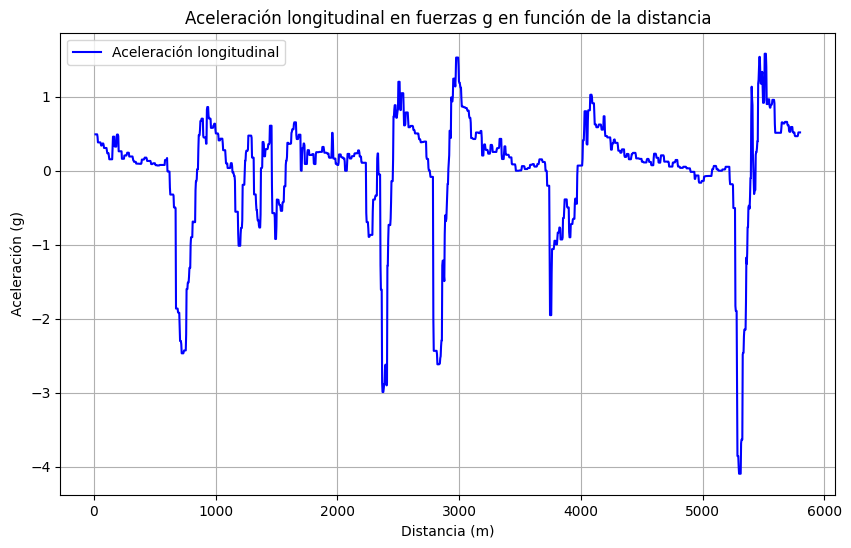

                X           Y     Distance           Z       Time  \
0     1763.000000 -723.000000    11.000000  737.000000   0.142000   
1     1763.919764 -724.061266    14.338524  736.648576   0.184171   
2     1764.839527 -725.122531    17.677047  736.297153   0.226342   
3     1765.759291 -726.183797    21.015571  735.945729   0.268512   
4     1766.679054 -727.245062    24.354095  735.594306   0.310683   
...           ...         ...          ...         ...        ...   
1730  1742.286426 -698.750278  5786.645905  745.225682  88.888459   
1731  1743.966764 -700.710671  5789.984429  744.669262  88.921844   
1732  1745.647101 -702.671065  5793.322953  744.112841  88.955230   
1733  1747.327438 -704.631458  5796.661476  743.556421  88.988615   
1734  1749.007775 -706.591851  5800.000000  743.000000  89.022000   

      DistanceToDriverAhead       Speed  nGear           RPM  Throttle  ...  \
0                169.566111  280.168421    7.0  11085.028080     100.0  ...   
1            

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Ejemplo de dataframe (reemplaza con tu data real)
data = {
    'speed': [300, 301, 302, 303, 304],  # km/h
    'distance': [1000, 1001, 1002, 1003, 1004],  # metros
    'time': [30.000, 30.033, 30.066, 30.099, 30.132]  # segundos
}
df = df_combined.copy()

# Convertir velocidad de km/h a m/s
df['speed_ms'] = df['Speed'] * (5 / 18)

# Calcular diferencias (Delta v y Delta t)
df['delta_v'] = df['speed_ms'].diff()  # Diferencia de velocidad
df['delta_t'] = df['Time'].diff()      # Diferencia de tiempo

# Calcular aceleración en m/s²
df['acceleration_ms2'] = df['delta_v'] / df['delta_t']

# Convertir aceleración a fuerzas g (1 g = 9.81 m/s²)
df_combined['longitudinal_aceleration'] = df['acceleration_ms2'] / 9.81
df['acceleration_g'] = df['acceleration_ms2'] / 9.81

# Graficar aceleración en g vs distancia
plt.figure(figsize=(10, 6))
plt.plot(df['Distance'], df['acceleration_g'], label='Aceleración longitudinal', color='blue')
plt.xlabel('Distancia (m)')
plt.ylabel('Aceleración (g)')
plt.title('Aceleración longitudinal en fuerzas g en función de la distancia')
plt.grid(True)
plt.legend()
plt.show()

# Mostrar dataframe (opcional)
print(df)

In [66]:
df_combined['lateral_g_filtered'] = df_cleaned['lateral_g_filtered']

In [17]:

fig = go.Figure()
fig.update_layout(
    width=1200,  # Ancho en píxeles
    height=800   # Alto en píxeles
)
fig.add_scatter(
    x=df_combined_driver1['lateral_g_filtered'],
    y=df_combined_driver1['longitudinal_aceleration'],
    mode='markers',
    name='Aceleración Longitudinal (g)',
    line=dict(color='blue', width=2),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Acceleration:</b> %{y:.2f}g<extra></extra>'
)

fig.show()

In [139]:
def create_f1_track_map(df, x_col='X', y_col='Y', faster_col='Faster', distance_col='Distance', 
                         segment_size=5, min_segments=3, track_name="Circuito F1",
                         driver1_name="Driver 1", driver2_name="Driver 2",
                         driver1_color='red', driver2_color='white', 
                         width=1000, height=800,
                         corners=None, sectors=None):
    """
    Crea un mapa del circuito de F1 donde cada segmento está coloreado según qué piloto es más rápido,
    incluyendo indicadores para curvas y sectores.
    
    Parameters:
        df: DataFrame con coordenadas X, Y y la columna Faster
        x_col: Nombre de la columna con coordenadas X
        y_col: Nombre de la columna con coordenadas Y
        faster_col: Nombre de la columna que indica qué piloto es más rápido (-1 o 1)
        distance_col: Nombre de la columna con la distancia
        segment_size: Tamaño de cada segmento para agrupar y determinar el color
        min_segments: Número mínimo de segmentos consecutivos para cambiar de color
        track_name: Nombre del circuito a mostrar en el título
        driver1_name: Nombre del primer piloto (Faster = -1)
        driver2_name: Nombre del segundo piloto (Faster = 1)
        driver1_color: Color para el primer piloto
        driver2_color: Color para el segundo piloto
        width: Ancho de la figura en píxeles
        height: Alto de la figura en píxeles
        corners: Lista de tuplas (distancia, número) para las curvas
                 Ejemplo: [(100, 1), (500, 2)] - Curva 1 a 100m, Curva 2 a 500m
        sectors: Lista de tuplas (distancia, número) para los sectores
                 Ejemplo: [(1000, 1), (3000, 2)] - Fin del Sector 1 a 1000m, Fin del Sector 2 a 3000m
        
    Returns:
        fig: Figura de Plotly con el mapa del circuito
    """
    import plotly.graph_objects as go
    import numpy as np
    import pandas as pd
    
    # Asegurarse de que el DataFrame esté ordenado por distancia
    df_sorted = df.sort_values(by=distance_col).reset_index(drop=True)
    
    # Crear grupos de segmentos basados en la distancia
    df_sorted['segment_group'] = (df_sorted[distance_col] / segment_size).astype(int)
    
    # Agrupar por segmento y calcular el valor promedio de 'Faster'
    segment_stats = df_sorted.groupby('segment_group').agg({
        x_col: 'mean',
        y_col: 'mean',
        faster_col: lambda x: 1 if x.mean() > 0 else -1,
        distance_col: 'mean'
    }).reset_index()
    
    # Aplicar filtro para evitar cambios rápidos de color (usar min_segments)
    segment_stats['filtered_faster'] = segment_stats[faster_col].copy()
    
    # Inicializar con el valor del primer segmento
    current_color = segment_stats.iloc[0]['filtered_faster']
    consecutive_count = 1
    
    # Aplicar filtro de segmentos mínimos
    for i in range(1, len(segment_stats)):
        if segment_stats.iloc[i][faster_col] == current_color:
            # Continúa la tendencia actual
            consecutive_count += 1
        else:
            # Potencial cambio de tendencia
            if consecutive_count >= min_segments:
                # La tendencia anterior era lo suficientemente larga, comienza una nueva
                current_color = segment_stats.iloc[i][faster_col]
                consecutive_count = 1
            else:
                # La tendencia anterior no era lo suficientemente larga, mantén el color anterior
                segment_stats.at[i, 'filtered_faster'] = current_color
                consecutive_count = 1
    
    # Crear grupos de segmentos continuos del mismo valor de 'filtered_faster'
    segment_stats['group_change'] = segment_stats['filtered_faster'].diff().ne(0).cumsum()
    
    # Crear figura
    fig = go.Figure()
    
    # Configurar el aspecto visual
    fig.update_layout(
        plot_bgcolor='black',
        paper_bgcolor='black',
        title_font=dict(size=24, color='white'),
        width=width,
        height=height,
        showlegend=False,
        legend=dict(
            orientation="h",
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            font=dict(color="white"),
            bgcolor="rgba(0,0,0,0.5)"
        ),
        margin=dict(l=20, r=20, t=60, b=20)
    )
    
    # Dibujar el contorno del circuito como referencia
    fig.add_trace(go.Scatter(
        x=df_sorted[x_col],
        y=df_sorted[y_col],
        mode='lines',
        line=dict(color='gray', width=1),
        opacity=0.3,
        showlegend=False
    ))
    
    # Contador para grupos ya mostrados en la leyenda
    driver1_in_legend = False
    driver2_in_legend = False
    
    # Para cada grupo de segmentos continuos del mismo color
    for group in segment_stats['group_change'].unique():
        group_data = segment_stats[segment_stats['group_change'] == group].copy()
        
        # Determinar el color basado en el valor de filtered_faster
        faster_value = group_data.iloc[0]['filtered_faster']
        
        if faster_value == -1:  # Driver 1 más rápido
            color = driver1_color
            faster_driver = f"{driver1_name} más rápido"
            show_in_legend = not driver1_in_legend
            driver1_in_legend = True
        else:  # Driver 2 más rápido
            color = driver2_color
            faster_driver = f"{driver2_name} más rápido"
            show_in_legend = not driver2_in_legend
            driver2_in_legend = True
        
        # Añadir segmento
        fig.add_trace(go.Scatter(
            x=group_data[x_col],
            y=group_data[y_col],
            mode='lines',
            line=dict(color=color, width=5),
            name=faster_driver,
            showlegend=False,
            hovertemplate=(
                f"<b>Distancia:</b> %{{customdata:.0f}}m<br>" +
                f"<b>{faster_driver}</b><extra></extra>"
            ),
            customdata=group_data[distance_col]
        ))
    
    # Añadir flecha de dirección (punto de inicio y dirección)
    start_point = df_sorted.iloc[0]
    point_10pct = df_sorted.iloc[int(len(df_sorted) * 0.01)]
    
    # Calcular la dirección
    dx = point_10pct[x_col] - start_point[x_col]
    dy = point_10pct[y_col] - start_point[y_col]
    
    # Normalizar la dirección y crear la punta de flecha
    length = np.sqrt(dx**2 + dy**2)
    dx, dy = dx/length, dy/length
    
    # Escalar adecuadamente la flecha
    x_range = df_sorted[x_col].max() - df_sorted[x_col].min()
    y_range = df_sorted[y_col].max() - df_sorted[y_col].min()
    scale = min(x_range, y_range) * 0.05
    
   
    # Add start/finish line (checkerboard pattern)
# This should go after adding the point of start marker

    # Create a proper start/finish line (checkerboard pattern)
    if len(df_sorted) > 1:
        # Get the direction of the track at the start point
        next_point_idx = 1
        dx = df_sorted.iloc[next_point_idx][x_col] - start_point[x_col]
        dy = df_sorted.iloc[next_point_idx][y_col] - start_point[y_col]
        
        # Normalize to get direction vector
        dist = np.sqrt(dx**2 + dy**2)
        if dist > 0:
            dx, dy = dx/dist, dy/dist
            
            # Calculate perpendicular vector (for width of start line)
            dx_perp, dy_perp = -dy, dx
            
            # Determine track width - adjust the value to match the width of your track visualization
            track_width = min(x_range, y_range) * 0.05
            
            # Number of checkerboard squares
            num_squares = 6
            
            # Create checkerboard pattern
            for i in range(num_squares):
                # Alternate black and white
                color = 'white' if i % 2 == 0 else 'black'
                
                # Calculate square positions
                offset = (i - num_squares/2) * (track_width/num_squares)
                
                # Square corners
                x0 = start_point[x_col] + dx_perp * offset
                y0 = start_point[y_col] + dy_perp * offset
                
                x1 = x0 + dx_perp * (track_width/num_squares)
                y1 = y0 + dy_perp * (track_width/num_squares)
                
                # Make the square slightly elongated in the track direction
                elongation = track_width * 0.4
                x0 -= dx * elongation/2
                y0 -= dy * elongation/2
                x1 -= dx * elongation/2
                y1 -= dy * elongation/2
                
                # Add the rectangle
                fig.add_shape(
                    type="path",
                    path=f"M {x0} {y0} L {x1} {y1} L {x1 + dx * elongation} {y1 + dy * elongation} L {x0 + dx * elongation} {y0 + dy * elongation} Z",
                    fillcolor=color,
                    line=dict(color=color, width=0),
                    layer="below"
                )
            
            # Add a label
            fig.add_annotation(
                x=start_point[x_col],
                y=start_point[y_col],
                text="START",
                showarrow=False,
                yshift=0,
                font=dict(color="white", size=12),
                bgcolor="rgba(0,0,0,0.7)",
                bordercolor="white",
                borderwidth=1,
                borderpad=2
            )
        
    # NUEVO: Añadir indicadores para las curvas
    if corners is not None and len(corners) > 0:
        for corner in corners:
            corner_distance, corner_number = corner
            
            # Encontrar el punto del circuito más cercano a esta distancia
            closest_idx = (df_sorted[distance_col] - corner_distance).abs().idxmin()
            corner_point = df_sorted.iloc[closest_idx]
            
            # Añadir marcador para la curva
            fig.add_trace(go.Scatter(
                x=[corner_point[x_col]],
                y=[corner_point[y_col]],
                mode='markers+text',
                marker=dict(color='cyan', size=8, symbol='circle', line=dict(color='black', width=1)),
                #text=f"T{corner_number}",
                #textposition="top center",
                #textfont=dict(size=14, color='cyan'),
                name=f"Curva {corner_number}",
                showlegend=False,
                hovertemplate=f"<b>Curva {corner_number}</b><br>Distancia: {corner_distance}m<extra></extra>"
            ))
            # Y añadir una anotación para el texto
            fig.add_annotation(
                x=corner_point[x_col],
                y=corner_point[y_col],
                text=f"T{corner_number}",
                showarrow=False,
                yshift=20,  # Desplazamiento vertical en píxeles
                xshift=0,  # Desplazamiento horizontal en píxeles
                font=dict(size=14, color='cyan'),
                bgcolor="rgba(0,0,0,1)",
                bordercolor="cyan",
                borderwidth=0,
                borderpad=2
            )
    
    # NUEVO: Añadir indicadores para los sectores
    if sectors is not None and len(sectors) > 0:
        for sector in sectors:
            sector_distance, sector_number = sector
            
            # Encontrar el punto del circuito más cercano a esta distancia
            closest_idx = (df_sorted[distance_col] - sector_distance).abs().idxmin()
            sector_point = df_sorted.iloc[closest_idx]
            
            # Añadir marcador para el sector
            fig.add_trace(go.Scatter(
                x=[sector_point[x_col]],
                y=[sector_point[y_col]],
                mode='markers+text',
                marker=dict(color='yellow', size=10, symbol='square', line=dict(color='black', width=1)),
                #text=f"            S{sector_number}",
                #textposition="top center",
                #textfont=dict(size=14, color='yellow'),
                name=f"Fin Sector {sector_number}",
                showlegend=False,
                hovertemplate=f"<b>Fin Sector {sector_number}</b><br>Distancia: {sector_distance}m<extra></extra>"
            ))
            fig.add_annotation(
                x=sector_point[x_col],
                y=sector_point[y_col],
                text=f"S{sector_number}",
                showarrow=False,
                yshift=-30,  # Desplazamiento vertical en píxeles
                xshift=0,  # Desplazamiento horizontal en píxeles
                font=dict(size=14, color='Yellow'),
                bgcolor="rgba(0,0,0,1)",
                bordercolor="cyan",
                borderwidth=0,
                borderpad=2
            )
            
            # Opcional: Añadir línea que cruza la pista para marcar el sector
            # Calcular la normal a la dirección de la pista en este punto
            if closest_idx > 0 and closest_idx < len(df_sorted) - 1:
                # Vector tangente a la pista (promedio de vectores a puntos anterior y siguiente)
                dx_prev = sector_point[x_col] - df_sorted.iloc[closest_idx-1][x_col]
                dy_prev = sector_point[y_col] - df_sorted.iloc[closest_idx-1][y_col]
                dx_next = df_sorted.iloc[closest_idx+1][x_col] - sector_point[x_col]
                dy_next = df_sorted.iloc[closest_idx+1][y_col] - sector_point[y_col]
                
                dx_tan = (dx_prev + dx_next) / 2
                dy_tan = (dy_prev + dy_next) / 2
                
                # Normalizar
                tan_length = np.sqrt(dx_tan**2 + dy_tan**2)
                if tan_length > 0:
                    dx_tan, dy_tan = dx_tan/tan_length, dy_tan/tan_length
                    
                    # Vector normal (perpendicular)
                    dx_norm, dy_norm = -dy_tan, dx_tan
                    
                    # Calcular puntos a ambos lados de la pista
                    margin = max(x_range, y_range) * 0.03  # Longitud de la línea del sector
                    x1 = sector_point[x_col] + dx_norm * margin
                    y1 = sector_point[y_col] + dy_norm * margin
                    x2 = sector_point[x_col] - dx_norm * margin
                    y2 = sector_point[y_col] - dy_norm * margin
                    
                    # Añadir línea para marcar el sector
                    fig.add_trace(go.Scatter(
                        x=[x1, x2],
                        y=[y1, y2],
                        mode='lines',
                        line=dict(color='yellow', width=2, dash='dash'),
                        showlegend=False
                    ))
    
    # Configurar ejes
    fig.update_xaxes(
        showgrid=False,
        zeroline=False,
        visible=False,
        scaleanchor="y",
        scaleratio=1,
    )
    
    fig.update_yaxes(
        showgrid=False,
        zeroline=False,
        visible=False
    )
    
    
    
    return fig

In [146]:
# Definir las posiciones de las curvas principales
# Formato: [posición en metros, número de curva]
corners = [
    [700, 1],
    [810, 2],
    [920, 3],
    [1500, 4],
    [1710, 5],
    [1850, 6],
    [2000, 7],
    [2230, 8],
    [2580, 9],
    [2700, 10],
    [3500, 11],
    [3785, 12],
    [4090, 13],
    [4900, 14],
    [5000, 15]
]

# Definir las posiciones de los sectores
# Formato: [posición en metros, número de sector]
sectors = [
    [1650, 1],  # Fin del sector 1
    [3900, 2],
    [5412, 3]    # Fin del sector 2
    # El sector 3 termina al final de la vuelta
]

# Crear el mapa del circuito con curvas y sectores
fig = create_f1_track_map(
    df=df_combined_delta,
    x_col='X',
    y_col='Y',
    faster_col='Faster',
    distance_col='Distance',
    segment_size=2,
    min_segments=20,
    track_name="Circuito de Suzuka",
    driver1_name="Norris",
    driver2_name="Piastri",
    driver1_color='orange',
    driver2_color='white',
    width=700,
    height=800,
    corners=corners,
    sectors=sectors
)

# Mostrar la figura
fig.show()

# Opcionalmente, guardar como imagen
fig.write_image("track_map_with_corners_sectors.png", scale=1)
fig.write_image("track_performance_map.png", scale=2)